---
title: "Wakao–Funazkri: the correlation that came from putting axial dispersion back in"
description: "Sh = 2 + 1.1 Sc^(1/3) Re^0.6 is what the packed-bed mass-transfer data say once the axial dispersion coefficient is no longer assumed to be zero. This page rebuilds the re-analysis that produced it, and tests the two fitted constants against the figure they were fitted on."
categories: [sec:A, struct:S3, tier:T1, data:tier4, phase:gas-solid]
date: 2026-08-02
---

# Wakao–Funazkri: the correlation that came from putting axial dispersion back in

**Catalog ID:** `A3.4` · **Structures:** `S3` (steady 1-D convection–diffusion–reaction) · **Tier:** T1

Almost every packed-bed model in use contains

$$\mathrm{Sh} = 2 + 1.1\,\mathrm{Sc}^{1/3}\,\mathrm{Re}^{0.6}$$

and almost nobody remembers what it replaced. Wakao and Funazkri did not measure
anything. They took thirty-five years of published mass-transfer data, noticed
that the people who produced it had solved the wrong equation, and solved the
right one.

**The wrong equation was plug flow.** A packed-bed transfer experiment measures
one number — how much of the transferring species leaves the bed. Turning that
into a coefficient needs a model of the bed, and if the model has no axial
dispersion in it then all of the observed depletion is charged to the film. At
low flow rates that is a large error, and it always runs the same way: it makes
the coefficient too small.

This page rebuilds that re-analysis. The bed model is a 1-D convection–
diffusion–reaction problem with Danckwerts boundary conditions, which is
something pymrm actually solves; the paper's Eq. 7 is its closed-form solution
and becomes a validation target rather than an input.

## Background

By 1978 the *j*-factor correlations for particle-to-fluid mass transfer had a
well-known and embarrassing property: extrapolated to low Reynolds number they
predict $\mathrm{Sh} \to 0$. A sphere sitting motionless in a stagnant fluid has
$\mathrm{Sh} = 2$. The correlations said the coefficient falls through that
floor and keeps going.

Everyone knew this. The usual explanation was that packed beds are not single
spheres. Wakao and Funazkri's answer is different and much sharper: **the low-Re
numbers are wrong, and they are wrong because of how they were extracted from
the raw measurements, not because of anything that happens in the bed.**

The argument runs like this. In a steady evaporation, sublimation or dissolution
experiment you measure the inlet and outlet concentrations. The mass balance
along the bed is

$$U \frac{\mathrm{d}C}{\mathrm{d}x} - D_{ax}\frac{\mathrm{d}^2 C}{\mathrm{d}x^2}
+ \frac{a}{\varepsilon_b}k_f\,(C - C_s) = 0 ,$$

which has **two** transport parameters, $D_{ax}$ and $k_f$, and only one
measurement. To get $k_f$ you must supply $D_{ax}$ from somewhere. Most of the
literature supplied $D_{ax} = 0$. Petrovic and Thodos, more carefully, supplied
the packed-bed asymptote $\mathrm{Pe} = d_p U / D_{ax} = 2$.

What Wakao et al. had just shown, in the companion paper, is that a *mass
transferring* species does not have the same axial dispersion coefficient as an
inert tracer, and that the stagnant contribution is far larger than the 0.6–0.8
everybody was using. Put that number in and the low-Re coefficients move — a
lot, for gases; not at all, for liquids.

The result is a correlation with the stagnant-sphere limit built in, which is
the one still in use.

## The published model

**The dispersion coefficient** (their Eqs. 1–3; $D_v$ is the molecular
diffusivity, $E^0$ the stagnant contribution):

$$D_{ax} = \frac{E^0}{\varepsilon_b} + \tfrac12 d_p U
\qquad\Longrightarrow\qquad
\frac{\varepsilon_b D_{ax}}{D_v} = \frac{E^0}{D_v} + \tfrac12\,\mathrm{Sc}\,\mathrm{Re}.$$

For a species being transferred *at the particle surface* — evaporation,
sublimation, dissolution, or a diffusion-controlled surface reaction — the
chart in the companion paper gives $E^0/D_v = 20$, so (Eq. 2)

$$\boxed{\ \frac{\varepsilon_b D_{ax}}{D_v} = 20 + 0.5\,\mathrm{Sc}\,\mathrm{Re}\ }$$

whereas under **inert** conditions (Eq. 3) the stagnant term is only
$(0.6\text{–}0.8)\,\varepsilon_b$, i.e. about 0.28 at
$\varepsilon_b = 0.40$. That factor of about 70 between the two stagnant terms is
the entire paper. (What moves the *data*, though, is the smaller factor against
the $\mathrm{Pe}=2$ assumption Petrovic and Thodos used, which result 1
computes.)

**The bed model** (Eq. 4) with Danckwerts boundary conditions (Eq. 5):

$$U \frac{\mathrm{d}C}{\mathrm{d}x} - D_{ax}\frac{\mathrm{d}^2 C}{\mathrm{d}x^2}
+ \frac{a}{\varepsilon_b}k_f (C - C_s) = 0,\qquad
U(C-C_{in}) = D_{ax}\frac{\mathrm{d}C}{\mathrm{d}x}\Big|_{0},\qquad
\frac{\mathrm{d}C}{\mathrm{d}x}\Big|_{L} = 0 .$$

**Its closed-form solution** (Eq. 7) — the classical closed-vessel first-order
result:

$$\frac{C_s - C_{exit}}{C_s - C_{in}}
= \frac{4A\exp\!\left[\dfrac{UL}{2D_{ax}}\right]}
{(1+A)^2\exp\!\left[A\dfrac{UL}{2D_{ax}}\right]-(1-A)^2\exp\!\left[-A\dfrac{UL}{2D_{ax}}\right]},
\qquad A = \sqrt{1 + \frac{4\,a\,k_f D_{ax}}{\varepsilon_b U^2}} .$$

**Its plug-flow limit** (Eq. 8), which is what the original authors inverted:

$$\frac{C_s - C_{exit}}{C_s - C_{in}} = \exp\!\left[-\frac{\mathrm{Sh}'}{\mathrm{Sc}\,\mathrm{Re}}aL\right].$$

$\mathrm{Sh}'$ is the Sherwood number you get by assuming $D_{ax}=0$;
$\mathrm{Sh}$ is the one you get from Eq. 7 with $D_{ax}$ from Eq. 2. **The
paper is the map from $\mathrm{Sh}'$ to $\mathrm{Sh}$.**

**The three correlations this page compares:**

| | |
|---|---|
| Eq. 12, this paper | $\mathrm{Sh} = 2 + 1.1\,\mathrm{Sc}^{1/3}\mathrm{Re}^{0.6}$, $3 \lesssim \mathrm{Re} \le 10^4$ |
| Eq. 9, Ranz–Marshall, single spheres | $\mathrm{Sh} = 2 + 0.6\,\mathrm{Sc}^{1/3}\mathrm{Re}^{1/2}$ |
| Eq. 11, Petrovic–Thodos, what Eq. 12 replaced | $\varepsilon_b j_D = 0.357\,\mathrm{Re}^{-0.359}$, $3 < \mathrm{Re} < 900$ |

All Reynolds numbers are $\mathrm{Re} = d_p U \varepsilon_b/\nu$, i.e. built on
the **superficial** velocity, as the paper's notation list specifies
($U$ itself is interstitial).

## Parameters and assumptions

Everything on this page is dimensionless, which is deliberate: the paper's own
argument is, and reconstructing particle diameters and bed heights for
thirty-eight literature sources would be inventing data.

Three groups carry all of it. With $a = 6(1-\varepsilon_b)/d_p$ for spheres and
$L/d_p$ the number of particle layers:

$$N = \frac{a k_f L}{\varepsilon_b U} = \frac{6(1-\varepsilon_b)\,\mathrm{Sh}\,(L/d_p)}{\mathrm{Sc}\,\mathrm{Re}},
\qquad
\mathrm{Pe}_L = \frac{UL}{D_{ax}} = \frac{\mathrm{Sc}\,\mathrm{Re}}{20 + 0.5\,\mathrm{Sc}\,\mathrm{Re}}\cdot\frac{L}{d_p},
\qquad
\theta = \frac{C_s - C_{exit}}{C_s - C_{in}} .$$

$N$ is the number of transfer units; $\mathrm{Pe}_L$ is the bed Péclet number.
Note that $\mathrm{Pe}_L/(L/d_p)$ — the *particle* Péclet number — tends to 2 as
$\mathrm{Sc}\,\mathrm{Re}\to\infty$, which is exactly the value Petrovic and
Thodos assumed everywhere.

**Assumptions taken from the paper.** All resistance in the fluid film, constant
surface concentration, steady state, spheres, all particles active, more than
two particle layers. Bed void fraction is taken as $\varepsilon_b = 0.40$;
$L/d_p$ is swept, because it is not reported per data set and the answer turns
out to depend on it only weakly.

**What the data collection excludes,** because it is part of the argument: all
non-steady measurements (pulse chromatography — too many parameters), liquid
data below $\mathrm{Re}=3$ (natural convection), Hurt's and Resnick's
naphthalene work (the vapour pressures in Table 3 disagree badly, and small
errors there are magnified), Hobson and Thodos' extraction runs, and Selke's ion
exchange.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, curve_fit
from scipy.stats import theilslopes
from scipy.sparse import eye_array
from scipy.sparse.linalg import spsolve
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "A3.4-wakao-funazkri"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

Four files. The parameter table holds every constant read off the page images —
the paper is a 1978 Elsevier scan whose text layer drops decimal points, so
nothing here was transcribed mechanically — plus the two axis calibrations, so
that everything below can be recomputed from pixel coordinates.

The other three come off the two figures, and they play different roles.

**Figure 2** is the gas-phase water-evaporation data *after* re-evaluation, at
the Schmidt number 0.6 printed inside the figure. These are data the correlation
was **checked against**.

**Figure 3** is the liquid-phase data, plotted as
$(\mathrm{Sh}-2)/\mathrm{Sc}^{1/3}$ against $\mathrm{Re}$. These are the data
$\alpha$ and $\beta$ were **fitted on** — the paper says so in as many words:
"In liquid-phase system $\mathrm{Sh}$ values are large and good to be used for
the determination of $\alpha$ and $\beta$." Its ordinate is already the reduced
group, so testing the correlation against it needs no Schmidt number and assumes
none: it is a plain power law $y = \alpha\,\mathrm{Re}^{\beta}$.

That file carries **six** marker sets, not one. Detecting markers on Figure 3
means first erasing the drawn correlation, and the width of the band erased
around it is a free knob that moves the fitted $\alpha$ by more than the
standard error that fit prints. So the whole sweep is shipped — one block of rows per
band half-width, `band_hw` — and result 5 computes the systematic uncertainty
from it instead of asserting insensitivity. `band_hw = 5` is the shipped set.

**Figure 3's drawn line** is the third file: the ink of the correlation the
figure prints inside itself, traced column by column. It is the calibration's
control experiment, because that curve is known in advance to be exactly
$1.1\,\mathrm{Re}^{0.6}$.

All were extracted by fitting the marker **shape** and taking the centre of the
fitted shape, not by locating a maximum of local ink density. The method, and
what it changed, are in the Validation section; the write-up for reuse is in
`queue_cases/A3.4/review/README.md`.

**Neither extraction has been confirmed by a maintainer yet.** The Figure 2
marker identifications were confirmed on 2026-08-02 — *"mostly symbols are
identified well, but often the marker is off centre"* — which is what prompted
the re-centring; the re-centred positions, the markers added on the same pass,
and the whole of Figure 3 are pending. Read the sidecars before using either
file. The page ships with that disclosed.

**Results 1, 2 and 3 — the ones that carry this page — depend on neither
file.** They are algebra and a solved boundary-value problem. The figures enter
only in results 4 and 5, where the page compares the correlation with
measurement, and that comparison is labelled as what it is.

In [3]:
fig2 = load_data("wakao-funazkri-1978-fig2.csv", page=PAGE)
fig3 = load_data("wakao-funazkri-1978-fig3.csv", page=PAGE)
line3 = load_data("wakao-funazkri-1978-fig3-line.csv", page=PAGE)
par = load_data("wakao-funazkri-1978-parameters.csv", page=PAGE)
obs_meta = load_meta("wakao-funazkri-1978-fig2.csv", page=PAGE)
liq_meta = load_meta("wakao-funazkri-1978-fig3.csv", page=PAGE)
P = dict(zip(par.quantity, par.value))

# Figure 2 carries one row per marker position ever recorded, so that the effect
# of the 2026-08-02 re-centring can be measured on a paired sample.  Several of
# the 2026-07-30 crosshairs turn out to be two marks on one glyph; `marker_id`
# groups them, and the point set the page uses is one row per distinct glyph.
obs = fig2.drop_duplicates("marker_id").reset_index(drop=True)

# Figure 3 carries one block of rows per erasure-band half-width.  BAND_SHIPPED
# is the set every headline number is computed on; the others are the systematic
# uncertainty, and result 5 uses all of them.
BAND_SHIPPED = 5
BANDS = sorted(fig3.band_hw.unique())
liq = fig3[fig3.band_hw == BAND_SHIPPED].reset_index(drop=True)

SC_FIG2 = P["Sc_figure2"]
ALPHA, BETA = P["alpha_eq12"], P["beta_eq12"]
E0 = P["E0_over_Dv"]                    # 20, eq. (2)
E0_INERT = (P["E0_over_Dv_inert_lo"], P["E0_over_Dv_inert_hi"])
SLOPE = P["dispersion_slope"]           # 0.5
PE_PT = P["Pe_petrovic"]                # 2
EPS_B = P["eps_b_figure2"]              # 0.40

Re_obs, Sh_obs = obs.Re.values, obs.Sh.values
Re_liq = liq.Re.values
Y_liq = liq.Sh_minus_2_over_Sc13.values      # (Sh - 2)/Sc^(1/3), the plotted group

print(f"Figure 2 (gas, Sc = {SC_FIG2}):    {len(obs)} distinct markers from "
      f"{len(fig2)} recorded positions,")
print(f"   Re {Re_obs.min():.1f} to {Re_obs.max():.0f}, Sh {Sh_obs.min():.1f} to {Sh_obs.max():.0f}")
print(f"Figure 3 (liquid, no Sc needed): {len(liq)} markers at the shipped "
      f"erasure band (half-width {BAND_SHIPPED} px),")
print(f"   Re {Re_liq.min():.1f} to {Re_liq.max():.0f}, "
      f"(Sh-2)/Sc^(1/3) {Y_liq.min():.2f} to {Y_liq.max():.1f}")
print("   the same figure at every other band setting: " +
      ", ".join(f"{h}->{int((fig3.band_hw == h).sum())}" for h in BANDS))
print(f"Figure 3's drawn correlation: {len(line3)} traced columns of its own ink")
print(f"\neq. (12):  Sh = 2 + {ALPHA} Sc^(1/3) Re^{BETA}")
print(f"eq. (2):   eps_b D_ax / D_v = {E0:.0f} + {SLOPE} Sc Re")
print(f"eq. (3):   eps_b D_ax*/ D_v = ({E0_INERT[0]}-{E0_INERT[1]}) eps_b + {SLOPE} Sc Re   [inert]")
print(f"\n{cite_data(obs_meta)}")
print(f"{cite_data(liq_meta)}")
print(f"\nreview status: Figure 2 {obs_meta['review']['status']}, "
      f"Figure 3 {liq_meta['review']['status']}")

Figure 2 (gas, Sc = 0.6):    79 distinct markers from 90 recorded positions,
   Re 4.2 to 919, Sh 3.5 to 84
Figure 3 (liquid, no Sc needed): 182 markers at the shipped erasure band (half-width 5 px),
   Re 3.0 to 2451, (Sh-2)/Sc^(1/3) 2.23 to 99.5
   the same figure at every other band setting: 0->210, 3->195, 5->182, 7->166, 10->147, 14->126
Figure 3's drawn correlation: 410 traced columns of its own ink

eq. (12):  Sh = 2 + 1.1 Sc^(1/3) Re^0.6
eq. (2):   eps_b D_ax / D_v = 20 + 0.5 Sc Re
eq. (3):   eps_b D_ax*/ D_v = (0.6-0.8) eps_b + 0.5 Sc Re   [inert]

Wakao, N.; Funazkri, T. (1978) — Chemical Engineering Science 33(10) 1375-1384 — doi:10.1016/0009-2509(78)85120-3 — digitised from Figure 2, journal page 1382 (PDF page 8)
Wakao, N.; Funazkri, T. (1978) — Chemical Engineering Science 33(10) 1375-1384 — doi:10.1016/0009-2509(78)85120-3 — digitised from Figure 3, journal page 1383 (PDF page 9)

review status: Figure 2 pending, Figure 3 pending


## PyMRM implementation

Two pieces. The first is the bed model, Eq. 4, discretised with pymrm's
operators. The second is the inversion that the paper performs by hand: given a
measured outlet, and a choice of dispersion coefficient, what $\mathrm{Sh}$
reproduces it.

**The boundary condition is where the physics is, so write it out.** pymrm's
`bc` uses the **outward** normal, $a\,\partial c/\partial n + b\,c = d$. On the
dimensionless bed $z = x/L$, $\theta = (C-C_s)/(C_{in}-C_s)$, the Danckwerts
inlet $U(C - C_{in}) = D_{ax}\,\mathrm{d}C/\mathrm{d}x$ becomes
$-\mathrm{Pe}_L^{-1}\theta' + \theta = 1$ at $z=0$, and at $z=0$ the outward
normal points in $-z$, so $\partial\theta/\partial n = -\theta'$ and the
coefficients are $a = 1/\mathrm{Pe}_L$, $b = 1$, $d = 1$. The outlet is plain
$\theta'(1)=0$, i.e. $a=1, b=0, d=0$ — which at the *right* boundary means
$+\theta' = 0$, the same equation, because a zero gradient does not care which
way the normal points. Anywhere else that sign flip matters.

The operators are assembled once per $(N, \mathrm{Pe}_L)$ and the problem is
linear, so there is no Newton loop — one sparse solve.

In [4]:
from pymrm import (construct_grad, construct_div, construct_convflux_upwind,
                   construct_boundary_value_matrices)


def theta_pymrm(N, Pe_L, n=1600, profile=False):
    """Outlet theta from eq. (4) with Danckwerts BCs, solved with pymrm.

    Dimensionless: theta' - Pe_L^-1 theta'' + N theta = 0 on 0 < z < 1.
    """
    shape = (n,)
    z_f = np.linspace(0.0, 1.0, n + 1)
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    # a dc/dn + b c = d, OUTWARD normal.
    #   z=0 (n = -z):  -Pe_L^-1 theta' + theta = 1   <- Danckwerts inlet, eq. (5)
    #   z=1 (n = +z):            theta'        = 0   <- Danckwerts outlet
    bc = ({"a": 1.0 / Pe_L, "b": 1.0, "d": 1.0},
          {"a": 1.0, "b": 0.0, "d": 0.0})
    conv, conv_bc = construct_convflux_upwind(shape, z_f, z_c, bc, v=1.0)
    grad, grad_bc = construct_grad(shape, z_f, z_c, bc)
    div = construct_div(shape, z_f, nu=0)          # nu=0: Cartesian slab
    jac = div @ (conv - grad / Pe_L) + N * eye_array(n, format="csr")
    rhs = -np.asarray((div @ (conv_bc - grad_bc / Pe_L)).todense()).ravel()
    th = spsolve(jac.tocsc(), rhs)
    Bv, Bg = construct_boundary_value_matrices(shape, z_f, z_c, bc=bc[1], bound_id=1)
    th_out = float((Bv @ th).ravel()[0] + np.asarray(Bg.todense()).ravel()[0])
    return (th, z_c, th_out) if profile else th_out


def theta_eq7(N, Pe_L):
    """Eq. (7): the closed-form outlet. Written with exp(A*Pe_L/2) factored out
    so it stays finite when the bed is long."""
    A = np.sqrt(1.0 + 4.0 * N / Pe_L)
    B = 0.5 * Pe_L
    return 4 * A * np.exp(B - A * B) / ((1 + A) ** 2 - (1 - A) ** 2 * np.exp(-2 * A * B))


def theta_eq8(N):
    """Eq. (8): the plug-flow limit, D_ax -> 0."""
    return np.exp(-N)


print("eq. (4) solved with pymrm vs eq. (7), the analytical outlet")
print(f"   {'N':>6}{'Pe_L':>7}{'eq. 7':>13}{'pymrm n=1600':>15}{'rel. err':>12}")
for N, Pe in ((1.0, 40.0), (5.0, 10.0), (0.5, 4.0), (20.0, 2.0)):
    ex, num = theta_eq7(N, Pe), theta_pymrm(N, Pe)
    print(f"   {N:6.1f}{Pe:7.1f}{ex:13.6e}{num:15.6e}{num/ex-1:+12.2e}")

eq. (4) solved with pymrm vs eq. (7), the analytical outlet
        N   Pe_L        eq. 7   pymrm n=1600    rel. err
      1.0   40.0 3.765349e-01   3.766366e-01   +2.70e-04
      5.0   10.0 2.387893e-02   2.393003e-02   +2.14e-03
      0.5    4.0 6.314912e-01   6.315108e-01   +3.10e-05
     20.0    2.0 2.104144e-03   2.106682e-03   +1.21e-03


### The inversion

The experiment fixes $\theta$. Which $\mathrm{Sh}$ you report depends entirely on
which $D_{ax}$ you assume, so the same measurement supports three different
answers:

| assumed dispersion | $\mathrm{Pe}_L$ | who used it |
|---|---|---|
| none, $D_{ax}=0$ | $\infty$ | most of the literature; gives $\mathrm{Sh}'$ |
| $\mathrm{Pe} = d_pU/D_{ax} = 2$ | $2(L/d_p)$ | Petrovic and Thodos |
| Eq. 2 | $\dfrac{\mathrm{Sc}\,\mathrm{Re}}{20+0.5\,\mathrm{Sc}\,\mathrm{Re}}\dfrac{L}{d_p}$ | this paper; gives $\mathrm{Sh}$ |

so the correction can be traced through a single measurement in both
directions.

In [5]:
def pe_particle(Sc_Re, law):
    """Particle Peclet number d_p U / D_ax under each dispersion assumption."""
    if law == "none":
        return np.inf
    if law == "pe2":
        return PE_PT
    if law == "eq2":
        return Sc_Re / (E0 + SLOPE * Sc_Re)
    raise ValueError(law)


def n_units(Sh, Re, Sc, L_dp, eps_b=EPS_B):
    """N = a k_f L / (eps_b U) with a = 6(1-eps_b)/d_p for spheres."""
    return 6.0 * (1.0 - eps_b) * Sh * L_dp / (Sc * Re)


def theta_of_Sh(Sh, Re, Sc, L_dp, law, eps_b=EPS_B):
    N = n_units(Sh, Re, Sc, L_dp, eps_b)
    pe = pe_particle(Sc * Re, law)
    return theta_eq8(N) if not np.isfinite(pe) else theta_eq7(N, pe * L_dp)


def Sh_of_theta(theta, Re, Sc, L_dp, law, eps_b=EPS_B):
    """Invert: what Sherwood number reproduces this outlet under `law`?"""
    k = 6.0 * (1.0 - eps_b) * L_dp / (Sc * Re)
    pe = pe_particle(Sc * Re, law)
    if not np.isfinite(pe):
        return -np.log(theta) / k
    f = lambda Sh: theta_eq7(Sh * k, pe * L_dp) - theta
    return brentq(f, 1e-10, 1e10, xtol=1e-13, rtol=1e-15)


def eq12(Re, Sc):
    return 2.0 + ALPHA * Sc ** (1 / 3) * np.asarray(Re, float) ** BETA


def eq9_ranz(Re, Sc):
    return 2.0 + P["alpha_ranz"] * Sc ** (1 / 3) * np.asarray(Re, float) ** P["beta_ranz"]


def eq11_petrovic(Re, Sc, eps_b=EPS_B):
    """eps_b j_D = 0.357 Re^-0.359, converted to a Sherwood number.
    j_D = (k_c/U_sup) Sc^(2/3), so Sh = j_D Re Sc^(1/3)."""
    j_d = P["jd_petrovic"] / eps_b * np.asarray(Re, float) ** P["jd_exp_petrovic"]
    return j_d * np.asarray(Re, float) * Sc ** (1 / 3)


for law in ("none", "pe2", "eq2"):
    print(f"{law:5s}: particle Pe at Sc.Re = 1, 10, 100, 1e4 -> " +
          ", ".join(f"{pe_particle(v, law):.3g}" for v in (1, 10, 100, 1e4)))

none : particle Pe at Sc.Re = 1, 10, 100, 1e4 -> inf, inf, inf, inf
pe2  : particle Pe at Sc.Re = 1, 10, 100, 1e4 -> 2, 2, 2, 2
eq2  : particle Pe at Sc.Re = 1, 10, 100, 1e4 -> 0.0488, 0.4, 1.43, 1.99


## Results

### 1. The whole paper is one number

Divide Eq. 2 by the Péclet-of-two assumption. Both have the same
$0.5\,\mathrm{Sc}\,\mathrm{Re}$ convective term; the difference is the stagnant
contribution, and it is a pure function of $\mathrm{Sc}\,\mathrm{Re}$:

$$\frac{D_{ax}^{\,\text{Eq. 2}}}{D_{ax}^{\,\mathrm{Pe}=2}}
= \frac{20 + 0.5\,\mathrm{Sc}\,\mathrm{Re}}{0.5\,\mathrm{Sc}\,\mathrm{Re}}
= 1 + \frac{40}{\mathrm{Sc}\,\mathrm{Re}} .$$

So the re-analysis can only matter where $\mathrm{Sc}\,\mathrm{Re} \lesssim 40$.
For a gas, $\mathrm{Sc}\approx 0.6$, that is $\mathrm{Re}\lesssim 70$ — most of
the range the correlations were fitted over. For a liquid,
$\mathrm{Sc}\approx 10^3$, it is $\mathrm{Re}\lesssim 0.04$ — below the range
the paper accepts data from at all.

**That single line predicts both halves of the paper's first conclusion**, and
it is why the gas data move and the liquid data do not.

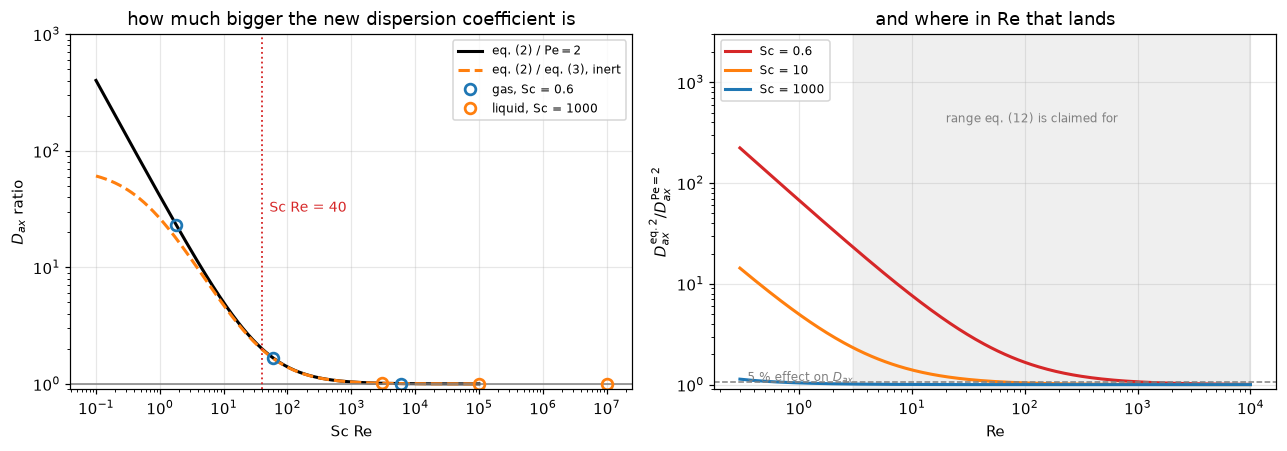

gas    Sc=   0.6:  D_ax doubles below Re =     66.7,   differs by 5 % below Re = 1.33e+03
liquid Sc=  1000:  D_ax doubles below Re =     0.04,   differs by 5 % below Re =      0.8

against the INERT coefficient of eq. (3) the factor is larger still:
   71x in the stagnant limit, because the stagnant term goes
   from 0.28 to 20. That is the comparison the companion
   paper makes; the Pe = 2 comparison is the one that moves the data.


In [6]:
def dax_ratio(Sc_Re):
    """eq. (2) over the Pe = 2 assumption. Both carry the same 0.5 Sc Re term,
    so the ratio is 1 + (E0/0.5)/Sc.Re = 1 + 40/Sc.Re."""
    return 1.0 + E0 / (SLOPE * np.asarray(Sc_Re, float))


ScRe = np.logspace(-1, 5, 400)
SCRE_DOUBLE = E0 / SLOPE                 # Sc.Re at which the coefficient doubles
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.2))

ax = axes[0]
ax.loglog(ScRe, dax_ratio(ScRe), "k-", lw=2,
          label=r"eq. (2) $/$ Pe$\,$=$\,$2")
ax.loglog(ScRe, (E0 + SLOPE * ScRe) / (np.mean(E0_INERT) * EPS_B + SLOPE * ScRe),
          "--", color="tab:orange", lw=2, label=r"eq. (2) $/$ eq. (3), inert")
ax.axhline(1.0, color="grey", lw=1)
ax.axvline(SCRE_DOUBLE, color="tab:red", lw=1.2, ls=":")
ax.text(SCRE_DOUBLE * 1.3, 30, f"Sc Re = {SCRE_DOUBLE:.0f}", color="tab:red", fontsize=9)
for lab, sc in (("gas, Sc = 0.6", 0.6), ("liquid, Sc = 1000", 1000.0)):
    res = np.array([3.0, 100.0, 10000.0])
    ax.plot(sc * res, dax_ratio(sc * res), "o", ms=7, mfc="none", mew=1.8, label=lab)
ax.set(xlabel="Sc Re", ylabel=r"$D_{ax}$ ratio", ylim=(0.9, 1e3),
       title="how much bigger the new dispersion coefficient is")
ax.legend(fontsize=8)

ax = axes[1]
Re = np.logspace(np.log10(0.3), 4, 300)
for sc, col in ((0.6, "tab:red"), (10.0, "tab:orange"), (1000.0, "tab:blue")):
    ax.loglog(Re, dax_ratio(sc * Re), color=col, lw=2, label=f"Sc = {sc:g}")
ax.axhline(1.05, color="grey", lw=1, ls="--")
ax.text(0.35, 1.07, "5 % effect on $D_{ax}$", fontsize=8, color="grey")
ax.axvspan(3, 1e4, color="grey", alpha=0.12)
ax.text(20, 400, "range eq. (12) is claimed for", fontsize=8, color="grey")
ax.set(xlabel="Re", ylabel=r"$D_{ax}^{\rm eq.2}/D_{ax}^{\rm Pe=2}$",
       ylim=(0.9, 3e3), title="and where in Re that lands")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

for sc, name in ((0.6, "gas   "), (1000.0, "liquid")):
    print(f"{name} Sc={sc:6g}:  D_ax doubles below Re = {SCRE_DOUBLE/sc:8.3g},"
          f"   differs by 5 % below Re = {E0/(SLOPE*sc*0.05):8.3g}")
inert_factor = E0 / (np.mean(E0_INERT) * EPS_B)
print(f"\nagainst the INERT coefficient of eq. (3) the factor is larger still:")
print(f"   {inert_factor:.0f}x in the stagnant limit, because the stagnant term goes")
print(f"   from {np.mean(E0_INERT)*EPS_B:.2f} to {E0:.0f}. That is the comparison the companion")
print(f"   paper makes; the Pe = 2 comparison is the one that moves the data.")

### 2. What that does to the reported Sherwood number

The $D_{ax}$ ratio is not the answer — the answer is what happens to the
*reported* $\mathrm{Sh}$ when the same measured outlet is re-inverted. Take a bed
that genuinely obeys Eq. 12, run it forward through Eq. 7 with the Eq. 2
dispersion coefficient to get the outlet such a bed would produce, then invert
Eq. 8 on that outlet — which is exactly what the original investigators did. The
gap between the two is the error the paper is correcting, and there is no free
parameter in it beyond the bed height.

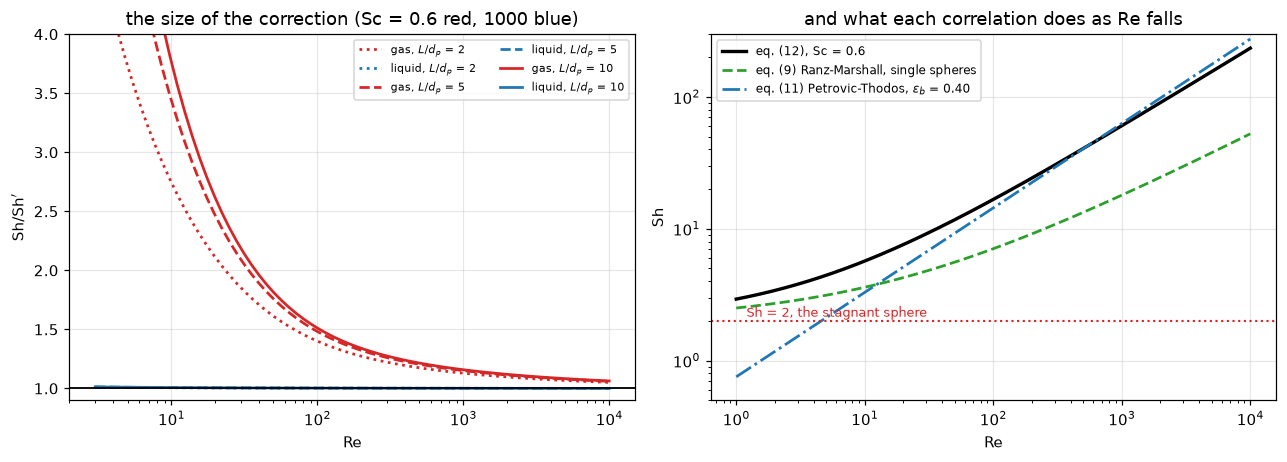

Sh/Sh' for a bed obeying eq. (12), five particle layers:
         Re   gas Sc=0.6   liquid Sc=1000
          3         6.92           1.0126
         10         3.44           1.0074
         30         2.09           1.0047
        100         1.48           1.0028
        300         1.26           1.0018
       1000         1.15           1.0011
       3000         1.10           1.0007
   a missing entry would mean the outlet is saturated to within 1e-10,
   so that no transfer coefficient can be recovered from it at all


In [7]:
def correction_factor(Re, Sc, L_dp, Sh_true=None):
    """Sh/Sh' for a bed whose true Sherwood number is Sh_true (eq. 12 by default).

    Forward: push Sh_true through eq. (7) with the eq. (2) dispersion coefficient
    to get the outlet such a bed would produce. Backward: invert eq. (8) on the
    same outlet, which is what the original investigators did. Nothing is fitted
    and there is no free parameter beyond the bed height.
    """
    Sh_true = eq12(Re, Sc) if Sh_true is None else Sh_true
    th = theta_of_Sh(Sh_true, Re, Sc, L_dp, "eq2")
    if th < 1e-10:      # bed saturated: the outlet no longer contains a coefficient
        return np.nan
    return Sh_true / Sh_of_theta(th, Re, Sc, L_dp, "none")


fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.3))
Re_g = np.logspace(np.log10(3), 4, 70)

ax = axes[0]
for L_dp, ls in ((2.0, ":"), (5.0, "--"), (10.0, "-")):
    r = np.array([correction_factor(x, SC_FIG2, L_dp) for x in Re_g])
    ax.semilogx(Re_g, r, ls, color="tab:red", lw=1.8, label=f"gas, $L/d_p$ = {L_dp:g}")
    r = np.array([correction_factor(x, 1000.0, L_dp) for x in Re_g])
    ax.semilogx(Re_g, r, ls, color="tab:blue", lw=1.8, label=f"liquid, $L/d_p$ = {L_dp:g}")
ax.axhline(1.0, color="k", lw=1.2)
ax.set(xlabel="Re", ylabel=r"$\mathrm{Sh}/\mathrm{Sh}'$", ylim=(0.9, 4),
       title="the size of the correction (Sc = 0.6 red, 1000 blue)")
ax.legend(fontsize=7.5, ncol=2)

ax = axes[1]
Re = np.logspace(np.log10(1), 4, 300)
ax.loglog(Re, eq12(Re, SC_FIG2), "k-", lw=2.2, label="eq. (12), Sc = 0.6")
ax.loglog(Re, eq9_ranz(Re, SC_FIG2), "--", color="tab:green", lw=1.8,
          label="eq. (9) Ranz-Marshall, single spheres")
ax.loglog(Re, eq11_petrovic(Re, SC_FIG2), "-.", color="tab:blue", lw=1.8,
          label=r"eq. (11) Petrovic-Thodos, $\varepsilon_b$ = 0.40")
ax.axhline(2.0, color="tab:red", lw=1.4, ls=":")
ax.text(1.2, 2.15, "Sh = 2, the stagnant sphere", color="tab:red", fontsize=8.5)
ax.set(xlabel="Re", ylabel="Sh", ylim=(0.5, 300),
       title="and what each correlation does as Re falls")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

print("Sh/Sh' for a bed obeying eq. (12), five particle layers:")
print(f"   {'Re':>8}{'gas Sc=0.6':>13}{'liquid Sc=1000':>17}")
for x in (3, 10, 30, 100, 300, 1000, 3000):
    print(f"   {x:8}{correction_factor(x, SC_FIG2, 5.0):13.2f}"
          f"{correction_factor(x, 1000.0, 5.0):17.4f}")
print("   a missing entry would mean the outlet is saturated to within 1e-10,")
print("   so that no transfer coefficient can be recovered from it at all")

### 3. Redoing the paper's own recalculation

The sharpest test available without touching a figure. Petrovic and Thodos'
Eq. 11 is *their data, already fitted*, under $\mathrm{Pe}=2$. Run it forward
through Eq. 7 at $\mathrm{Pe}=2$ to recover the outlet, then invert Eq. 7 again
with Eq. 2's dispersion coefficient. If Wakao and Funazkri's arithmetic is
right, what comes out should be Eq. 12.

Nothing is fitted here. Both correlations, both dispersion laws and the bed
model are printed in the paper.

In [8]:
Re_t = np.array([30, 50, 100, 200, 300, 500, 900])
rows = []
for L_dp in (10.0, 20.0, 40.0):
    out = []
    for x in Re_t:
        th = theta_of_Sh(eq11_petrovic(x, SC_FIG2), x, SC_FIG2, L_dp, "pe2")
        out.append(Sh_of_theta(th, x, SC_FIG2, L_dp, "eq2"))
    rows.append((L_dp, np.array(out)))

print("Petrovic-Thodos eq. (11) re-analysed with eq. (2), against eq. (12)")
print(f"   {'Re':>6}{'eq. 11':>9}{'eq. 12':>9}" +
      "".join(f"{'L/dp='+str(int(l)):>11}" for l, _ in rows))
for i, x in enumerate(Re_t):
    print(f"   {x:6}{eq11_petrovic(x, SC_FIG2):9.2f}{eq12(x, SC_FIG2):9.2f}" +
          "".join(f"{r[i]:11.2f}" for _, r in rows))

dev = {int(L): np.abs(r / eq12(Re_t, SC_FIG2) - 1) for L, r in rows}
band = Re_t >= 100
print()
for L, d in dev.items():
    print(f"   L/d_p = {L:2d}:  100 <= Re <= 900: mean |dev| {d[band].mean()*100:5.2f} %,"
          f" worst {d[band].max()*100:5.2f} %   |   whole table: mean"
          f" {d.mean()*100:5.2f} %, worst {d.max()*100:5.2f} %")
REANAL = dev[10][band]
print(f"\n   -> over 100 <= Re <= 900, where both correlations are inside their")
print(f"      stated ranges, the recalculation returns eq. (12) to {REANAL.mean()*100:.1f} % on")
print(f"      average and {REANAL.max()*100:.1f} % at worst, and the answer barely moves when the")
print(f"      bed height is changed fourfold - which is what makes it a test of")
print(f"      the paper rather than of L/d_p. Nothing here was fitted.")
print(f"      Below Re ~ 50 the inversion stops being well conditioned: the bed")
print(f"      saturates and the outlet stops containing a transfer coefficient.")
print(f"      That is a property of the experiments, not of the numerics, and it")
print(f"      is the reason low-Re gas data scatter as badly as they do.")

Petrovic-Thodos eq. (11) re-analysed with eq. (2), against eq. (12)
       Re   eq. 11   eq. 12    L/dp=10    L/dp=20    L/dp=40
       30     6.66     9.14      10.68      10.98      11.14
       50     9.24    11.70      12.34      12.53      12.64
      100    14.41    16.70      16.54      16.65      16.71
      200    22.47    24.29      23.90      23.97      24.01
      300    29.14    30.43      30.27      30.32      30.35
      500    40.43    40.62      41.26      41.29      41.31
      900    58.93    56.95      59.50      59.53      59.54

   L/d_p = 10:  100 <= Re <= 900: mean |dev|  1.83 %, worst  4.48 %   |   whole table: mean  4.49 %, worst 16.87 %
   L/d_p = 20:  100 <= Re <= 900: mean |dev|  1.63 %, worst  4.52 %   |   whole table: mean  5.06 %, worst 20.16 %
   L/d_p = 40:  100 <= Re <= 900: mean |dev|  1.54 %, worst  4.55 %   |   whole table: mean  5.37 %, worst 21.89 %

   -> over 100 <= Re <= 900, where both correlations are inside their
      stated ranges, the re

### 4. The digitised gas-phase data

Figure 2 is the paper's own before-and-after picture: re-evaluated
$\mathrm{Sh}$ for water evaporation at $\mathrm{Sc}=0.6$, with Eq. 12 drawn
through it, Ranz–Marshall below it, and the Petrovic–Thodos line cutting across
it. Rebuilt from the extracted markers, with deviation defined once as
$(\text{model}-\text{measured})/\text{measured}$.

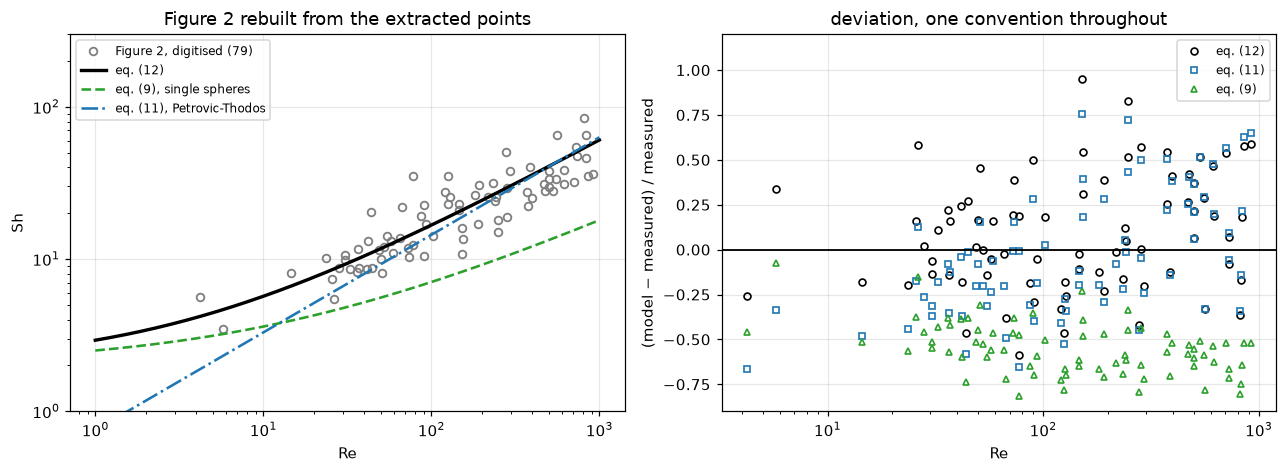

against the 79 digitised markers:
   eq. (12) this paper : mean |dev|  27.2 %   bias   +9.7 %
   eq. (11) Petrovic-T : mean |dev|  28.7 %   bias   -3.1 %
   eq.  (9) Ranz-Marsh: mean |dev|  55.1 %   bias  -55.1 %

bias by Reynolds decade - this is the shape of the argument:
          Re band   n    eq. 12    eq. 11     eq. 9
             1-30   7     +6.7%    -31.9%    -37.2%
           30-100  27     +1.4%    -19.3%    -52.2%
          100-300  23     +8.5%     -0.3%    -58.7%
         300-1100  22    +22.2%    +22.8%    -60.7%


In [9]:
Re_c = np.logspace(0, 3, 300)
d12 = eq12(Re_obs, SC_FIG2) / Sh_obs - 1
d09 = eq9_ranz(Re_obs, SC_FIG2) / Sh_obs - 1
d11 = eq11_petrovic(Re_obs, SC_FIG2) / Sh_obs - 1

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
ax = axes[0]
ax.loglog(Re_obs, Sh_obs, "o", ms=5, mfc="none", mew=1.2, color="tab:grey",
          label=f"Figure 2, digitised ({len(Re_obs)})")
ax.loglog(Re_c, eq12(Re_c, SC_FIG2), "k-", lw=2.2, label="eq. (12)")
ax.loglog(Re_c, eq9_ranz(Re_c, SC_FIG2), "--", color="tab:green", lw=1.7,
          label="eq. (9), single spheres")
ax.loglog(Re_c, eq11_petrovic(Re_c, SC_FIG2), "-.", color="tab:blue", lw=1.7,
          label="eq. (11), Petrovic-Thodos")
ax.set(xlabel="Re", ylabel="Sh", title="Figure 2 rebuilt from the extracted points",
       ylim=(1, 300))
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
for d, c, m, lab in ((d12, "k", "o", "eq. (12)"),
                     (d11, "tab:blue", "s", "eq. (11)"),
                     (d09, "tab:green", "^", "eq. (9)")):
    ax.semilogx(Re_obs, d, m, ms=4.5, mfc="none", mew=1.1, color=c, label=lab)
ax.axhline(0, color="k", lw=1.2)
ax.set(xlabel="Re", ylabel="(model $-$ measured) / measured", ylim=(-0.9, 1.2),
       title="deviation, one convention throughout")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"against the {len(Re_obs)} digitised markers:")
for d, lab in ((d12, "eq. (12) this paper "), (d11, "eq. (11) Petrovic-T "),
               (d09, "eq.  (9) Ranz-Marsh")):
    print(f"   {lab}: mean |dev| {np.abs(d).mean()*100:5.1f} %   bias {d.mean()*100:+6.1f} %")

print("\nbias by Reynolds decade - this is the shape of the argument:")
print(f"   {'Re band':>14}{'n':>4}{'eq. 12':>10}{'eq. 11':>10}{'eq. 9':>10}")
for lo, hi in ((1, 30), (30, 100), (100, 300), (300, 1100)):
    m = (Re_obs >= lo) & (Re_obs < hi)
    if m.sum() < 2:
        continue
    print(f"   {str(lo)+'-'+str(hi):>14}{m.sum():4d}{d12[m].mean()*100:+9.1f}%"
          f"{d11[m].mean()*100:+9.1f}%{d09[m].mean()*100:+9.1f}%")

### 5. The correlation against the data it was fitted to

Figure 2 is a *check*; Figure 3 is the *fit*. Its ordinate is already
$(\mathrm{Sh}-2)/\mathrm{Sc}^{1/3}$, so the correlation reduces to a power law
$y = \alpha\,\mathrm{Re}^{\beta}$ with no Schmidt number anywhere, and fitting
that power law to the digitised markers is a direct test of the two printed
constants.

**It is also a trap, and this page walked into it once.** A digitised refit of a
1978 figure has three uncertainties, and only one of them is the standard error
that a regression prints:

1. the **axes** may be mis-calibrated — and this figure carries its own control,
   because the correlation is drawn *inside* it;
2. the **marker set** depends on how much of that drawn line is erased before
   the markers are detected;
3. the **estimator** — a straight line in log–log and an unweighted fit in
   linear $y$ are different questions, and the answer is not the same.

Take them in that order. Nothing about $\alpha$ and $\beta$ below is worth
reading until the first two are quantified.

**5a. The calibration, checked against a curve whose answer is
known in advance.** Figure 3 prints its own correlation across the middle of the
plot and labels it $(\mathrm{Sh}-2)/\mathrm{Sc}^{1/3} = 1.1\,\mathrm{Re}^{0.6}$.
Trace that ink, invert the axis calibration, fit a power law to it, and the
answer must come back 1.1 and 0.6. Anything else is calibration error, measured
on an object with no scientific content at all.

The first pass of this extraction ran that control, got $\alpha$ a couple of per
cent high and $\beta$ about one per cent low, and reported it in the dataset
sidecar as confirmation. It was not: it was a **symptom**, and it never reached
the page. The two axes of the figure disagree — the decade ticks on the
left-hand axis sit some five pixels above those on the right, because the page
render is rotated by about a fifth of a degree — and averaging the two sides,
which is what the first pass did, is right in the middle of the plot and wrong
at both ends. The shipped calibration interpolates instead: the ordinate origin
*and* the decade height are functions of the column.

In [10]:
# the two ordinate calibrations of Figure 3, both read from the parameter file
CX0, PXX3 = P["col0_fig3"], P["pxdec_x_fig3"]
R0L, R0R = P["row0_fig3_left"], P["row0_fig3_right"]
PYL, PYR = P["pxdec_y_fig3_left"], P["pxdec_y_fig3_right"]
TCL, TCR = P["tickcol_fig3_left"], P["tickcol_fig3_right"]
R0F, PYF = P["row0_fig3"], P["pxdec_y_fig3"]


def re_of_col(c):
    return 10.0 ** ((np.asarray(c, float) - CX0) / PXX3)


def _yscale(c):
    t = (np.asarray(c, float) - TCL) / (TCR - TCL)
    return R0L + (R0R - R0L) * t, PYL + (PYR - PYL) * t


def y_skew(r, c):
    """SHIPPED calibration: row origin and decade height linear in the column."""
    r0, py = _yscale(c)
    return 10.0 ** ((r0 - np.asarray(r, float)) / py)


def row_skew(y, c):
    r0, py = _yscale(c)
    return r0 - py * np.log10(np.asarray(y, float))


def y_flat(r):
    """SUPERSEDED calibration: one row origin for the whole plot."""
    return 10.0 ** ((R0F - np.asarray(r, float)) / PYF)


def row_flat(y):
    return R0F - PYF * np.log10(np.asarray(y, float))


# the shipped Re / y columns must be exactly what the skew calibration gives
chk = np.abs(y_skew(liq.row_px.values, liq.col_px.values) / Y_liq - 1).max()
assert chk < 5e-4, chk
print(f"parameters reproduce the shipped ordinate to {chk:.1e} relative")
print(f"tick skew: y = 1 sits at row {R0L:.2f} under the left axis (column "
      f"{TCL:.0f}) and {R0R:.2f} under the right (column {TCR:.0f}),")
print(f"   i.e. the plot is tilted by {R0R-R0L:+.2f} px over its "
      f"{TCR-TCL:.0f} px width, {np.degrees(np.arctan((R0R-R0L)/(TCR-TCL))):.3f} degrees.")

# where the drawn line ACTUALLY is, against where each calibration computes it
Re_line = re_of_col(line3.col_px.values)
comp_line = ALPHA * Re_line ** BETA
off_flat = line3.row_px.values - row_flat(comp_line)
off_skew = line3.row_px.values - row_skew(comp_line, line3.col_px.values)
print(f"\ndrawn ink minus computed position of {ALPHA} Re^{BETA}, "
      f"{len(line3)} traced columns")
print(f"   {'Re band':>14}{'n':>5}{'flat cal.':>12}{'skew cal.':>12}")
for lo, hi in ((3, 10), (10, 100), (100, 1000), (1000, 10000)):
    m = (Re_line >= lo) & (Re_line < hi)
    if m.sum() >= 5:
        print(f"   {str(lo)+'-'+str(hi):>14}{m.sum():5d}"
              f"{off_flat[m].mean():+10.2f} px{off_skew[m].mean():+10.2f} px")
print(f"   {'all':>14}{len(line3):5d}{off_flat.mean():+10.2f} px"
      f"{off_skew.mean():+10.2f} px")
print(f"   spread about the mean: {off_flat.std():.2f} px flat, "
      f"{off_skew.std():.2f} px skew-corrected")

parameters reproduce the shipped ordinate to 8.1e-05 relative
tick skew: y = 1 sits at row 1144.28 under the left axis (column 153) and 1149.92 under the right (column 1742),
   i.e. the plot is tilted by +5.64 px over its 1589 px width, 0.203 degrees.

drawn ink minus computed position of 1.1 Re^0.6, 410 traced columns
          Re band    n   flat cal.   skew cal.
             3-10   98     -3.37 px     -1.53 px
           10-100   34     +0.67 px     +0.97 px
         100-1000  131     +2.34 px     +1.98 px
       1000-10000  128     +0.12 px     -1.10 px
              all  410     -0.07 px     -0.00 px
   spread about the mean: 3.83 px flat, 3.54 px skew-corrected


In [11]:
def powerlaw_fit(re, y):
    """alpha, beta and their standard errors from a straight line in log-log."""
    lx, ly = np.log10(np.asarray(re, float)), np.log10(np.asarray(y, float))
    p, cov = np.polyfit(lx, ly, 1, cov=True)
    sd = np.sqrt(np.diag(cov))
    alpha = 10.0 ** p[1]
    return alpha, float(p[0]), alpha * np.log(10.0) * sd[1], float(sd[0])


def powerlaw_fit_linear(re, y):
    """The same power law fitted by UNWEIGHTED least squares in linear y, which
    is the metric the paper's own Figure 4 plots on."""
    p, _ = curve_fit(lambda r, a, b: a * r ** b, np.asarray(re, float),
                     np.asarray(y, float), p0=[ALPHA, BETA], maxfev=20000)
    return float(p[0]), float(p[1])


def alpha_at_fixed_beta(re, y, beta=BETA, how="log"):
    """alpha with the exponent held at the printed value.

    The loss function still has to be chosen, so all three are available:
    `log` is the geometric mean of the ratios y/Re^beta (equal relative weight,
    the same metric as the free log fit), `lin` is unweighted least squares in
    linear y, and `med` is the median ratio.
    """
    re, y = np.asarray(re, float), np.asarray(y, float)
    if how == "log":
        return float(10.0 ** np.mean(np.log10(y) - beta * np.log10(re)))
    if how == "lin":
        return float(np.sum(y * re ** beta) / np.sum(re ** (2 * beta)))
    if how == "med":
        return float(np.median(y / re ** beta))
    raise ValueError(how)


def line_control(cal):
    """Fit the drawn correlation ink under calibration `cal`.

    One median per 100-px column bin, then a fit to the bin medians: the traced
    columns are not uniformly spread (markers sitting on the line remove whole
    stretches of it), so an unbinned fit weights the crowded columns.
    """
    bc, by = [], []
    for lo in range(300, 1600, 100):
        m = (line3.col_px >= lo) & (line3.col_px < lo + 100)
        if m.sum() >= 5:
            bc.append(line3.col_px[m].mean())
            by.append(np.median(cal(m)))
    a, b, _, _ = powerlaw_fit(re_of_col(np.array(bc)), np.array(by))
    return a, b, len(bc)


A_LN_F, B_LN_F, NBIN = line_control(
    lambda m: y_flat(line3.row_px[m].values))
A_LN_S, B_LN_S, _ = line_control(
    lambda m: y_skew(line3.row_px[m].values, line3.col_px[m].values))
print(f"the drawn correlation, refitted from its own ink ({NBIN} column bins).")
print(f"   The right answer is known: alpha = {ALPHA}, beta = {BETA}.")
print(f"   {'calibration':>26}{'alpha':>10}{'beta':>10}{'err(a)':>9}{'err(b)':>9}")
for lab, a, b in (("flat, as first shipped", A_LN_F, B_LN_F),
                  ("skew-corrected", A_LN_S, B_LN_S)):
    print(f"   {lab:>26}{a:10.4f}{b:10.4f}{100*(a/ALPHA-1):+8.1f}%"
          f"{100*(b/BETA-1):+8.1f}%")
print(f"\n   -> the line WAS drawn from the printed constants. Correcting the")
print(f"      skew takes the control from {100*(A_LN_F/ALPHA-1):+.1f} % / "
      f"{100*(B_LN_F/BETA-1):+.1f} % to {100*(A_LN_S/ALPHA-1):+.1f} % / "
      f"{100*(B_LN_S/BETA-1):+.1f} % - about a")
print(f"      {abs(1-(A_LN_S/ALPHA-1)/(A_LN_F/ALPHA-1))*100:.0f} % reduction in the "
      f"alpha error - and what is left is inside the")
print(f"      width of the drawn stroke rather than an axis error. The correction")
print(f"      moves the MARKER fit by a comparable amount, and in the same")
print(f"      direction: that is the point of running the control at all.")

the drawn correlation, refitted from its own ink (10 column bins).
   The right answer is known: alpha = 1.1, beta = 0.6.
                  calibration     alpha      beta   err(a)   err(b)
       flat, as first shipped    1.1262    0.5949    +2.4%    -0.9%
               skew-corrected    1.1073    0.5984    +0.7%    -0.3%

   -> the line WAS drawn from the printed constants. Correcting the
      skew takes the control from +2.4 % / -0.9 % to +0.7 % / -0.3 % - about a
      72 % reduction in the alpha error - and what is left is inside the
      width of the drawn stroke rather than an axis error. The correction
      moves the MARKER fit by a comparable amount, and in the same
      direction: that is the point of running the control at all.


**5b. The erasure band.** Figure 3's markers merge into chains
along the drawn correlation, and the detector cannot see them until that line is
erased. Most of it goes by morphology — a 61 px straight-ink opening, which no
13–23 px glyph can survive — but the remainder is removed by *computed position*,
in a band of chosen half-width around $1.1\,\mathrm{Re}^{0.6}$. That band is the
one mechanism in the pipeline that can destroy a real marker, its width is a
free choice, and it moves the fitted $\alpha$ by more than the standard error
that fit prints.

So it is not chosen and disclosed in prose; the whole sweep is extracted, and
the answer is reported as a function of it.

In [12]:
print("the Figure 3 refit as a function of the erasure band half-width")
print(f"   {'band':>6}{'n':>5}{'alpha':>9}{'beta':>9}{'a (lin.)':>10}"
      f"{'b (lin.)':>10}{'a | b=0.6':>11}{'  (flat)':>10}{'on line':>9}")
BAND = {}
for hw in BANDS:
    g = fig3[fig3.band_hw == hw]
    re, y = g.Re.values, g.Sh_minus_2_over_Sc13.values
    a, b, _, _ = powerlaw_fit(re, y)
    la, lb = powerlaw_fit_linear(re, y)
    af = alpha_at_fixed_beta(re, y)
    aff = alpha_at_fixed_beta(re, y_flat(g.row_px.values))
    on = int((np.abs(g.row_px.values
                     - row_skew(ALPHA * re ** BETA, g.col_px.values)) < 5).sum())
    BAND[int(hw)] = dict(n=len(g), a=a, b=b, la=la, lb=lb, af=af, aff=aff, on=on)
    star = " <- shipped" if hw == BAND_SHIPPED else ""
    print(f"   {hw:6.0f}{len(g):5d}{a:9.4f}{b:9.4f}{la:10.4f}{lb:10.4f}"
          f"{af:11.4f}{aff:10.4f}{on:9d}{star}")

lo_hw, hi_hw = min(BAND), max(BAND)
print(f"\n   'on line' counts fitted centres within 5 px of the computed position")
print(f"   of the drawn correlation - the markers the band is deciding about.")

# what exactly does switching the band off add?  Match the two point sets.
off, shipped = fig3[fig3.band_hw == lo_hw], fig3[fig3.band_hw == BAND_SHIPPED]
gained = np.array([not (((shipped.col_px - r.col_px) ** 2
                         + (shipped.row_px - r.row_px) ** 2) < 25).any()
                   for r in off.itertuples()])
d_line = np.abs(off.row_px.values
                - row_skew(ALPHA * off.Re.values ** BETA, off.col_px.values))
print(f"   turning the band off gains {int(gained.sum())} centres the shipped set "
      f"does not have.")
print(f"      their distance from the drawn line: median "
      f"{np.median(d_line[gained]):.1f} px, {int((d_line[gained] < 5).sum())} within 5 px")
print(f"      their fit score:                    median "
      f"{np.median(off.fit_score.values[gained]):.3f}, against "
      f"{np.median(shipped.fit_score):.3f} for the shipped set")
print(f"   Widening the band to {hi_hw} px instead leaves "
      f"{BAND[BAND_SHIPPED]['n']-BAND[hi_hw]['n']} fewer markers than the shipped set.")
A_SPREAD = (min(v["a"] for v in BAND.values()), max(v["a"] for v in BAND.values()))
AF_LOG = (min(min(v["af"], v["aff"]) for v in BAND.values()),
          max(max(v["af"], v["aff"]) for v in BAND.values()))
_af_all, _a_all = [], []
for hw in BANDS:
    g = fig3[fig3.band_hw == hw]
    re_g = re_of_col(g.col_px.values)
    for yy in (g.Sh_minus_2_over_Sc13.values, y_flat(g.row_px.values)):
        _af_all += [alpha_at_fixed_beta(re_g, yy, how=h) for h in ("log", "lin", "med")]
        _a_all += [powerlaw_fit(re_g, yy)[0], powerlaw_fit_linear(re_g, yy)[0],
                   10.0 ** theilslopes(np.log10(yy), np.log10(re_g))[1]]
AF_SPREAD = (min(_af_all), max(_af_all))
A_FULL = (min(_a_all), max(_a_all))
B_SPREAD = (min(v["b"] for v in BAND.values()), max(v["b"] for v in BAND.values()))
print(f"\n   across the whole sweep:  free alpha {A_SPREAD[0]:.3f} to {A_SPREAD[1]:.3f}"
      f"   free beta {B_SPREAD[0]:.4f} to {B_SPREAD[1]:.4f}")
print(f"   alpha at beta = {BETA}, over both calibrations AND all six bands, in the")
print(f"      log metric of the two columns above:   {AF_LOG[0]:.4f} to {AF_LOG[1]:.4f}"
      f"   ({100*(AF_LOG[0]/ALPHA-1):+.1f} % to {100*(AF_LOG[1]/ALPHA-1):+.1f} %)")
print(f"      and over three estimators as well:     {AF_SPREAD[0]:.4f} to "
      f"{AF_SPREAD[1]:.4f}   ({100*(AF_SPREAD[0]/ALPHA-1):+.1f} % to "
      f"{100*(AF_SPREAD[1]/ALPHA-1):+.1f} %)")
print(f"   the free alpha over the same six bands x two calibrations x three")
print(f"      estimators:                         {A_FULL[0]:.4f} to {A_FULL[1]:.4f}"
      f"   ({100*(A_FULL[0]/ALPHA-1):+.1f} % to {100*(A_FULL[1]/ALPHA-1):+.1f} %)")
print(f"   Held at beta = {BETA} the answer is never more than "
      f"{100*(AF_SPREAD[1]/ALPHA-1):.1f} % above the printed {ALPHA};")
print(f"   left free it reaches {100*(A_FULL[1]/ALPHA-1):.0f} % above. That contrast "
      f"is the result of this section.")

the Figure 3 refit as a function of the erasure band half-width
     band    n    alpha     beta  a (lin.)  b (lin.)  a | b=0.6    (flat)  on line
        0  210   1.2959   0.5589    1.0513    0.6013     1.0980    1.1008       28
        3  195   1.3274   0.5526    1.1615    0.5837     1.0976    1.1004       17
        5  182   1.3437   0.5496    1.1566    0.5844     1.1000    1.1029        3 <- shipped
        7  166   1.3596   0.5466    1.1650    0.5822     1.1010    1.1040        0
       10  147   1.4169   0.5361    1.2145    0.5727     1.1061    1.1095        0
       14  126   1.4400   0.5328    1.2286    0.5719     1.1143    1.1179        0

   'on line' counts fitted centres within 5 px of the computed position
   of the drawn correlation - the markers the band is deciding about.
   turning the band off gains 35 centres the shipped set does not have.
      their distance from the drawn line: median 3.6 px, 20 within 5 px
      their fit score:                    median 0.684, a

The direction is the one the extraction predicted: erasing more
of the line removes the markers lying *on* it, which are the ones nearest the
printed correlation, so $\alpha$ climbs and $\beta$ falls. Three things follow
that must be said out loud.

**The shipped setting is mid-range, not conservative.** Turning the band off
altogether still leaves the morphological removal doing most of the work and
recovers 28 more markers on balance — 35 centres the shipped set does not have,
against 7 of the shipped ones it does not find. It is not shipped because those
extra centres pile up
on the drawn line itself — that is what the last column of the table measures —
and score visibly worse than the rest, so they are more likely
to be surviving fragments of the line than markers rescued from it. That is a
judgement, it is stated here rather than buried, and the cost of being wrong
about it is the width of the sweep.

**The sweep is wider than the standard error this page used to quote.** The free
$\alpha$ moves further across defensible band settings than the regression's own
iid error bar allows for, and about half as far as the honest clustered one that
5d computes. Extraction uncertainty is not a footnote to the sampling error
here; it is of the same order, which is the whole reason the sweep is shipped as
data rather than described.

**One number barely moves.** $\alpha$ with $\beta$ held at the printed 0.6
varies by under 2 % across the whole sweep *and* across both axis calibrations,
against 18–31 % for the free $\alpha$ over the band alone; on the shipped set it
equals the printed value. It is not a fixed point — the estimator and the
starting $\mathrm{Re}$ both move it by a few per cent, and the next cell prints
both — but it is the only quantity on this figure that comes back near
1.1 under everything tried.

In [13]:
print(f"the fit family on the shipped set: {len(liq)} markers, "
      f"band half-width {BAND_SHIPPED} px")
print(f"   printed:  alpha = {ALPHA}   beta = {BETA}")
print(f"\n   {'calibration':>16}{'estimator':>26}{'alpha':>10}{'beta':>10}")
FAMILY = {}
for cal, ycal in (("flat", y_flat(liq.row_px.values)),
                  ("skew-corrected", Y_liq)):
    a, b, sa, sb = powerlaw_fit(Re_liq, ycal)
    la, lb = powerlaw_fit_linear(Re_liq, ycal)
    ts = theilslopes(np.log10(ycal), np.log10(Re_liq))
    FAMILY[(cal, "log")] = (a, b, sa, sb)
    FAMILY[(cal, "lin")] = (la, lb)
    FAMILY[(cal, "ts")] = (10.0 ** ts[1], ts[0])
    print(f"   {cal:>16}{'least squares in log y':>26}{a:10.4f}{b:10.4f}")
    print(f"   {'':>16}{'least squares in linear y':>26}{la:10.4f}{lb:10.4f}")
    print(f"   {'':>16}{'Theil-Sen in log y':>26}{10.0**ts[1]:10.4f}{ts[0]:10.4f}")
    for h, lab in (("log", "b fixed: geometric mean"),
                   ("lin", "b fixed: linear-y LS"),
                   ("med", "b fixed: median ratio")):
        FAMILY[(cal, "fix", h)] = alpha_at_fixed_beta(Re_liq, ycal, how=h)
        print(f"   {'':>16}{lab:>26}{FAMILY[(cal, 'fix', h)]:10.4f}{BETA:10.4f}")

A_LIQ, B_LIQ, A_LIQ_SE, B_LIQ_SE = FAMILY[("skew-corrected", "log")]
A_LIQ_LIN, B_LIQ_LIN = FAMILY[("skew-corrected", "lin")]
A_FIXED_B = FAMILY[("skew-corrected", "fix", "log")]
_fix = [FAMILY[(c, "fix", h)] for c in ("flat", "skew-corrected")
        for h in ("log", "lin", "med")]
_free = [FAMILY[("flat", "log")][0], FAMILY[("skew-corrected", "log")][0],
         FAMILY[("flat", "lin")][0], FAMILY[("skew-corrected", "lin")][0],
         FAMILY[("flat", "ts")][0], FAMILY[("skew-corrected", "ts")][0]]
print(f"\n   the printed pair is {ALPHA} / {BETA}. Fixing beta does not remove the")
print(f"   estimator choice, so all three are shown - but it collapses its effect:")
print(f"   with beta free, alpha spans {min(_free):.3f} to {max(_free):.3f} over the "
      f"six rows above")
print(f"   ({100*(min(_free)/ALPHA-1):+.0f} % to {100*(max(_free)/ALPHA-1):+.0f} % of "
      f"{ALPHA}); with beta held at {BETA} it spans {min(_fix):.3f} to {max(_fix):.3f} "
      f"({100*(min(_fix)/ALPHA-1):+.1f} %")
print(f"   to {100*(max(_fix)/ALPHA-1):+.1f} %), and in the same log metric the free "
      f"fits use it is {A_FIXED_B:.4f}.")

print("\nthe log-space fit, started at increasing Reynolds number:")
print(f"   {'Re >=':>7}{'n':>5}{'alpha':>9}{'beta':>9}{'a | b=0.6':>11}")
LIQ_CUT = {}
for cut in (3, 5, 10, 20, 30, 50):
    m = Re_liq >= cut
    a, b, _, _ = powerlaw_fit(Re_liq[m], Y_liq[m])
    af = alpha_at_fixed_beta(Re_liq[m], Y_liq[m])
    LIQ_CUT[cut] = (int(m.sum()), a, b, af)
    print(f"   {cut:7d}{m.sum():5d}{a:9.3f}{b:9.4f}{af:11.4f}")
print(f"\n   THE LAST COLUMN MATTERS AS MUCH AS THE FIRST TWO. alpha at beta = "
      f"{BETA} is")
print(f"   {LIQ_CUT[3][3]:.4f} on the whole sample and {LIQ_CUT[50][3]:.4f} from "
      f"Re >= 50 - a {100*(LIQ_CUT[50][3]/LIQ_CUT[3][3]-1):+.1f} % swing, larger than")
print(f"   anything the band or the calibration does and comparable with the")
print(f"   estimator. So the beta-fixed alpha is not a fixed point of the analysis:")
print(f"   it is a number that comes back near {ALPHA} under every combination tried,")
print(f"   never more than {100*(AF_SPREAD[1]/ALPHA-1):.1f} % above it and at worst "
      f"{abs(100*(AF_SPREAD[0]/ALPHA-1)):.1f} % below, while the free alpha")
print(f"   over the band-by-calibration-by-estimator grid runs up to "
      f"{100*(A_FULL[1]/ALPHA-1):.0f} % high.")

the fit family on the shipped set: 182 markers, band half-width 5 px
   printed:  alpha = 1.1   beta = 0.6

        calibration                 estimator     alpha      beta
               flat    least squares in log y    1.3667    0.5460
                    least squares in linear y    1.1723    0.5815
                           Theil-Sen in log y    1.2119    0.5521
                      b fixed: geometric mean    1.1029    0.6000
                         b fixed: linear-y LS    1.0411    0.6000
                        b fixed: median ratio    1.0529    0.6000
     skew-corrected    least squares in log y    1.3437    0.5496
                    least squares in linear y    1.1566    0.5844
                           Theil-Sen in log y    1.1899    0.5558
                      b fixed: geometric mean    1.1000    0.6000
                         b fixed: linear-y LS    1.0469    0.6000
                        b fixed: median ratio    1.0518    0.6000

   the printed pair is 1.1 / 0.6.

**5c. The estimator, and why the choice is not a detail.** Within each block of
that table the rows are the same 182 points and the same model under different
loss functions. Least squares in $\log y$ weights every marker
equally in *relative* terms; least squares in linear $y$ is dominated by the
large values, which here means the high-$\mathrm{Re}$ end. They disagree by more
than the difference either of them has with the printed pair.

**The paper does not say which one it used, and the figures do not settle it.**
Figure 4 is where it pools the gas and liquid data against
$(\mathrm{Sc}^{1/3}\mathrm{Re}^{0.6})^2$ and writes *"it is seen that the data
are well correlated by eqn (12)"*. That figure is drawn on **log–log** axes, as
is every figure in the paper, and the square is taken — in the authors' own
words — *"to enlarge the plot in the x-axis direction"*: a presentational choice,
not a weighting. A two-significant-figure correlation drawn through data pooled
from thirty-eight sources in 1978 does not have a recoverable loss function.
Choosing the log-metric fit and calling its disagreement with 1.1 and 0.6 an
error in the paper is therefore asserting a property of the estimator as if it
were a property of the data.

**5d. And the standard errors are not what they look like.** The $\pm$ figures
printed above are ordinary least-squares standard errors, which assume the
residuals are independent and identically distributed. These are neither. The
182 markers come from eleven laboratories, each contributing a contiguous window
in $\mathrm{Re}$ with its own systematic offset, and the mean function is
mis-specified over the range. Both are measurable.

In [14]:
lx, ly = np.log10(Re_liq), np.log10(Y_liq)
o = np.argsort(lx); lxs, lys = lx[o], ly[o]
p1 = np.polyfit(lxs, lys, 1)
res = lys - np.polyval(p1, lxs)
p2, c2 = np.polyfit(lxs, lys, 2, cov=True)
QUAD_Z = abs(p2[0]) / np.sqrt(c2[0, 0])
print(f"is a straight line in log-log even the right model?")
print(f"   quadratic term {p2[0]:+.4f} +/- {np.sqrt(c2[0,0]):.4f}"
      f"   -> {QUAD_Z:.1f} standard errors from zero")
print(f"   residual autocorrelation in log-Re order: " +
      ", ".join(f"lag {L} {np.corrcoef(res[:-L], res[L:])[0,1]:+.2f}"
                for L in (1, 2, 3, 5, 10)))

# Newey-West, and a cluster bootstrap over the same Re bins the page bins on
X = np.column_stack([np.ones(len(lxs)), lxs])
XtXi = np.linalg.inv(X.T @ X)
HAC = {}
for L in (5, 10, 20):
    S = (res[:, None, None] ** 2 * X[:, :, None] * X[:, None, :]).sum(0)
    for l in range(1, L + 1):
        w = 1.0 - l / (L + 1.0)
        u = (res[l:] * res[:-l])[:, None, None] * X[l:, :, None] * X[:-l, None, :]
        S = S + w * (u.sum(0) + u.sum(0).T)
    hs = np.sqrt(np.diag(XtXi @ S @ XtXi))
    HAC[L] = (A_LIQ * np.log(10.0) * hs[0], hs[1])

CL_EDGES = np.array([3, 6, 12, 25, 50, 100, 200, 500, 1200, 3000], float)
cid = np.digitize(Re_liq, CL_EDGES)
uq = np.unique(cid)
rng = np.random.default_rng(20260802)
bs_a, bs_b = [], []
for _ in range(4000):
    idx = np.concatenate([np.where(cid == u)[0]
                          for u in rng.choice(uq, size=len(uq), replace=True)])
    q = np.polyfit(lx[idx], ly[idx], 1)
    bs_a.append(10.0 ** q[1]); bs_b.append(q[0])
bs_a, bs_b = np.array(bs_a), np.array(bs_b)
CI_A = (float(np.percentile(bs_a, 2.5)), float(np.percentile(bs_a, 97.5)))
CI_B = (float(np.percentile(bs_b, 2.5)), float(np.percentile(bs_b, 97.5)))
SE_A_CL, SE_B_CL = float(bs_a.std(ddof=1)), float(bs_b.std(ddof=1))

print(f"\nwhat the error bar on the free fit is worth, "
      f"alpha = {A_LIQ:.3f} / beta = {B_LIQ:.4f}")
print(f"   {'error model':>34}{'SE(alpha)':>11}{'SE(beta)':>11}"
      f"{'z(alpha)':>10}{'z(beta)':>9}")
rows_err = [("ordinary least squares (iid)", A_LIQ_SE, B_LIQ_SE)]
rows_err += [(f"Newey-West HAC, L = {L}", *HAC[L]) for L in (5, 10, 20)]
rows_err += [(f"cluster bootstrap, {len(uq)} Re bins", SE_A_CL, SE_B_CL)]
for lab, sa, sb in rows_err:
    print(f"   {lab:>34}{sa:11.4f}{sb:11.4f}"
          f"{abs(A_LIQ-ALPHA)/sa:10.1f}{abs(B_LIQ-BETA)/sb:9.1f}")
print(f"\n   cluster bootstrap 95 % interval:  alpha {CI_A[0]:.3f} to {CI_A[1]:.3f}"
      f"   (printed {ALPHA})")
print(f"                                     beta  {CI_B[0]:.4f} to {CI_B[1]:.4f}"
      f"  (printed {BETA})")
HALF_BAND = 0.5 * (A_SPREAD[1] - A_SPREAD[0])
print(f"\n   and the sampling error is not the whole story. The extraction band alone")
print(f"   spans alpha {A_SPREAD[0]:.3f} to {A_SPREAD[1]:.3f}, a half-width of "
      f"{HALF_BAND:.3f} - {HALF_BAND/A_LIQ_SE:.1f}x the standard error this page")
print(f"   used to quote and {HALF_BAND/SE_A_CL:.1f}x the clustered one. So the "
      f"extraction dominates the iid")
print(f"   error bar outright and is comparable with the honest one. Adding the two")
print(f"   in quadrature, quoting +/-{A_LIQ_SE:.3f} understates the uncertainty on "
      f"alpha by a")
print(f"   factor of about {np.hypot(SE_A_CL, HALF_BAND)/A_LIQ_SE:.0f}.")

is a straight line in log-log even the right model?
   quadratic term +0.0558 +/- 0.0111   -> 5.0 standard errors from zero
   residual autocorrelation in log-Re order: lag 1 +0.04, lag 2 +0.09, lag 3 +0.11, lag 5 +0.12, lag 10 +0.12



what the error bar on the free fit is worth, alpha = 1.344 / beta = 0.5496
                          error model  SE(alpha)   SE(beta)  z(alpha)  z(beta)
         ordinary least squares (iid)     0.0520     0.0090       4.7      5.6
                Newey-West HAC, L = 5     0.0740     0.0121       3.3      4.2
               Newey-West HAC, L = 10     0.0882     0.0145       2.8      3.5
               Newey-West HAC, L = 20     0.0995     0.0169       2.5      3.0
         cluster bootstrap, 9 Re bins     0.1320     0.0227       1.8      2.2

   cluster bootstrap 95 % interval:  alpha 1.043 to 1.532   (printed 1.1)
                                     beta  0.5083 to 0.5981  (printed 0.6)

   and the sampling error is not the whole story. The extraction band alone
   spans alpha 1.296 to 1.440, a half-width of 0.072 - 1.4x the standard error this page
   used to quote and 0.5x the clustered one. So the extraction dominates the iid
   error bar outright and is comparable with the hone

**So what survives?**

**The printed pair is not rejected by this figure.** The 95 % cluster-bootstrap
interval on $\alpha$ contains 1.1. The interval on $\beta$ falls just short of
0.6, and the linear-metric fit returns a $\beta$ inside it. Before any of that,
the extraction band moves $\alpha$ by more than the standard error the page used
to quote, and by about half the honest one. There is no defensible reading in
which this page has caught an error in the paper, and an earlier draft of it
claimed one.

**What does survive is that the figure returns the printed $\alpha$ once
$\beta$ is held at 0.6.** On the whole sample, in the same log metric the free
fits use, it is 1.1000 against the printed 1.1. Vary the erasure band and the
axis calibration and it stays inside 1.098–1.118; vary the estimator as well and
it stays inside 1.007–1.118 — within 9 % of the printed value and never more
than 2 % above it. The free $\alpha$ over the same choices runs 1.05 to 1.47,
i.e. up to a third high. **That contrast is the result:** given $\beta = 0.6$
the data return $\alpha$; left free, $\alpha$ is largely whatever the estimator
and the erasure band make it.

**Two things move the $\beta$-fixed $\alpha$, and both are printed rather than
waved away.** The estimator moves it by about 5 % — least squares in linear $y$
gives 1.047 where the log metric gives 1.100 — and the starting
$\mathrm{Re}$ moves it by 7 %, down to 1.02 from $\mathrm{Re}\ge 50$. Neither
takes it far from 1.1, and the second is the low-$\mathrm{Re}$ excess again,
which is the next paragraph.

**And a real, weaker statement about shape.** The free exponent comes out below
0.6 under every estimator on the shipped set, because the markers below
$\mathrm{Re}\approx 10$ sit above the drawn line on the printed page — visible,
not an extraction artefact, and the starting-$\mathrm{Re}$ table shows the fit
walking *through* the printed pair as they are dropped and out the other side:
$\beta$ reaches 0.6 between starts of $\mathrm{Re}=10$ and 20 and keeps
climbing, $\alpha$ crosses 1.1 over the same two rows and keeps falling. The
paper half says this itself: it sets aside liquid data below
$\mathrm{Re}\approx 3$ as possibly affected by natural convection, which
inflates the transfer coefficient. What the figure shows is that the
effect has not finished by $\mathrm{Re}=3$. That is a statement about the low-Re
liquid data, not about the arithmetic — and the residual carries a significant
quadratic term, so a two-parameter power law is not the right description of
this cloud in the first place.

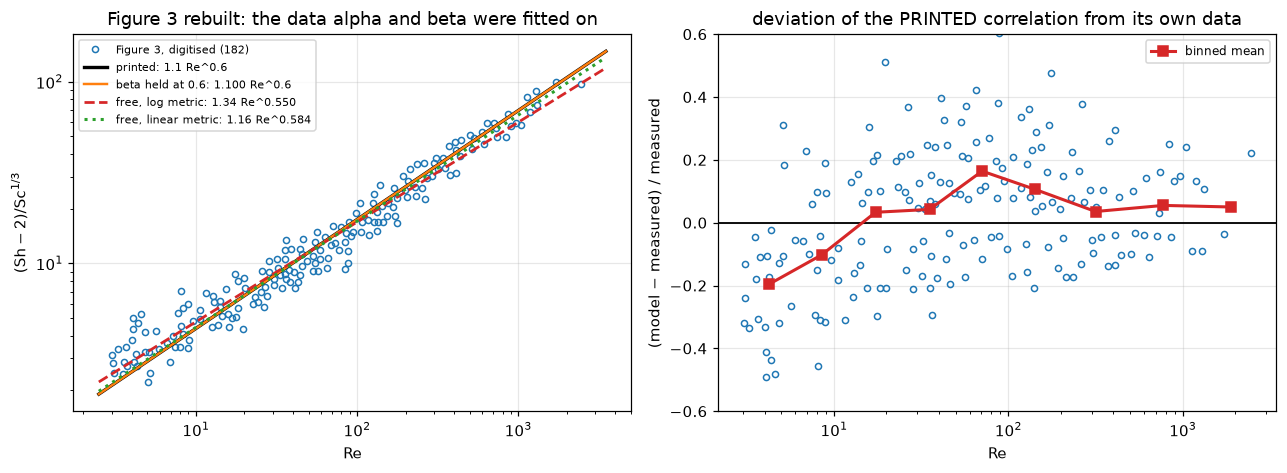

eq. (12) against the 182 liquid markers it was fitted on:
   mean |dev| 17.6 %   bias +2.3 %
eq. (12) against the 79 gas markers it was checked against:
   mean |dev| 27.2 %   bias +9.7 %

binned mean deviation on the liquid data (the shape of the low-Re excess):
          Re band    n   mean dev
              3-6   23     -19.6%
             6-12   17     -10.3%
            12-25   21      +3.3%
            25-50   30      +4.2%
           50-100   25     +16.4%
          100-200   23     +10.7%
          200-500   23      +3.6%
         500-1200   16      +5.5%
        1200-3000    4      +5.0%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
Re_l = np.logspace(np.log10(2.5), np.log10(3500), 300)

ax = axes[0]
ax.loglog(Re_liq, Y_liq, "o", ms=4, mfc="none", mew=1.0, color="tab:blue",
          label=f"Figure 3, digitised ({len(liq)})")
ax.loglog(Re_l, ALPHA * Re_l ** BETA, "k-", lw=2.2,
          label=f"printed: {ALPHA} Re^{BETA}")
ax.loglog(Re_l, A_FIXED_B * Re_l ** BETA, "-", color="tab:orange", lw=1.6,
          label=f"beta held at {BETA}: {A_FIXED_B:.3f} Re^{BETA}")
ax.loglog(Re_l, A_LIQ * Re_l ** B_LIQ, "--", color="tab:red", lw=1.8,
          label=f"free, log metric: {A_LIQ:.2f} Re^{B_LIQ:.3f}")
ax.loglog(Re_l, A_LIQ_LIN * Re_l ** B_LIQ_LIN, ":", color="tab:green", lw=2.0,
          label=f"free, linear metric: {A_LIQ_LIN:.2f} Re^{B_LIQ_LIN:.3f}")
ax.set(xlabel="Re", ylabel=r"$(\mathrm{Sh}-2)/\mathrm{Sc}^{1/3}$",
       title="Figure 3 rebuilt: the data alpha and beta were fitted on")
ax.legend(fontsize=7.5, loc="upper left")

ax = axes[1]
dev_liq = ALPHA * Re_liq ** BETA / Y_liq - 1.0
ax.semilogx(Re_liq, dev_liq, "o", ms=4, mfc="none", mew=1.0, color="tab:blue")
ax.axhline(0, color="k", lw=1.2)
edges = np.array([3, 6, 12, 25, 50, 100, 200, 500, 1200, 3000], float)
cen, mean = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (Re_liq >= lo) & (Re_liq < hi)
    if m.sum() >= 3:
        cen.append(np.sqrt(lo * hi)); mean.append(dev_liq[m].mean())
ax.semilogx(cen, mean, "s-", color="tab:red", lw=2, ms=6, label="binned mean")
ax.set(xlabel="Re", ylabel="(model $-$ measured) / measured", ylim=(-0.6, 0.6),
       title="deviation of the PRINTED correlation from its own data")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

LIQ_MAD = float(np.abs(dev_liq).mean())
LIQ_BIAS = float(dev_liq.mean())
print(f"eq. (12) against the {len(liq)} liquid markers it was fitted on:")
print(f"   mean |dev| {100*LIQ_MAD:.1f} %   bias {100*LIQ_BIAS:+.1f} %")
print(f"eq. (12) against the {len(obs)} gas markers it was checked against:")
d12_gas = eq12(Re_obs, SC_FIG2) / Sh_obs - 1.0
print(f"   mean |dev| {100*np.abs(d12_gas).mean():.1f} %   "
      f"bias {100*d12_gas.mean():+.1f} %")
print("\nbinned mean deviation on the liquid data (the shape of the low-Re excess):")
print(f"   {'Re band':>14}{'n':>5}{'mean dev':>11}")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (Re_liq >= lo) & (Re_liq < hi)
    if m.sum() >= 3:
        print(f"   {str(int(lo))+'-'+str(int(hi)):>14}{m.sum():5d}"
              f"{100*dev_liq[m].mean():+10.1f}%")

## Validation

Eight checks, in decreasing order of how much they can be argued with. The first
three involve no data at all. Check 8 injects a defect into each of the
load-bearing ones — check 1 and results 3 and 5 — recomputes **every** metric
under **every** defect, and then lists what each check cannot see. (Check 3 gets
no injected defect: it is in the blind-spot list as unable to fail.)

**1. pymrm against Eq. 7.** The paper's closed form is the exact solution of the
problem pymrm discretises, so grid refinement must converge onto it. Upwind
convection is first order, so the error must halve when the cell count doubles,
and one Richardson step must remove almost all of it.

In [16]:
print("grid convergence of the pymrm solve against eq. (7)")
worst_rich = 0.0
for N, Pe in ((1.0, 40.0), (5.0, 10.0), (0.5, 4.0), (20.0, 2.0)):
    ex = theta_eq7(N, Pe)
    errs, vals = [], []
    for n in (200, 400, 800, 1600, 3200):
        v = theta_pymrm(N, Pe, n)
        vals.append(v); errs.append(v / ex - 1)
    ratios = [errs[i] / errs[i + 1] for i in range(len(errs) - 1)]
    rich = 2 * vals[-1] - vals[-2]                 # h -> 0 extrapolation
    worst_rich = max(worst_rich, abs(rich / ex - 1))
    print(f"   N={N:5.1f} Pe_L={Pe:5.1f}  err(n=200)={errs[0]:+.2e} -> "
          f"err(n=3200)={errs[-1]:+.2e}   halving ratios "
          + " ".join(f"{r:.2f}" for r in ratios)
          + f"   Richardson {rich/ex-1:+.1e}")
print(f"   -> first order confirmed (ratios 2.00), and one extrapolation step")
print(f"      lands within {worst_rich:.1e} of eq. (7). The closed form and the")
print(f"      discretisation are the same problem.")

grid convergence of the pymrm solve against eq. (7)
   N=  1.0 Pe_L= 40.0  err(n=200)=+2.16e-03 -> err(n=3200)=+1.35e-04   halving ratios 2.00 2.00 2.00 2.00   Richardson +4.9e-08
   N=  5.0 Pe_L= 10.0  err(n=200)=+1.72e-02 -> err(n=3200)=+1.07e-03   halving ratios 2.01 2.00 2.00 2.00   Richardson -9.3e-07
   N=  0.5 Pe_L=  4.0  err(n=200)=+2.48e-04 -> err(n=3200)=+1.55e-05   halving ratios 2.00 2.00 2.00 2.00   Richardson +2.5e-09
   N= 20.0 Pe_L=  2.0  err(n=200)=+9.87e-03 -> err(n=3200)=+6.02e-04   halving ratios 2.03 2.01 2.01 2.00   Richardson -2.0e-06
   -> first order confirmed (ratios 2.00), and one extrapolation step
      lands within 2.0e-06 of eq. (7). The closed form and the
      discretisation are the same problem.


**2. Eq. 7 collapses onto Eq. 8 when the dispersion is switched off.** The
paper asserts this in one sentence — "eqn (7) reduces to eqn (8), when not only
$D_{ax}=0$ but also $\mathrm{Sc}\,\mathrm{Re}$ is sufficiently large" — and it
is the reason the liquid data survive untouched.

In [17]:
print("eq. (7) -> eq. (8) as Pe_L -> infinity, at N = 2")
N = 2.0
for Pe in (2, 10, 50, 200, 1e3, 1e4, 1e5):
    print(f"   Pe_L = {Pe:8.0f}: eq. 7 = {theta_eq7(N, Pe):.8f}"
          f"   eq. 8 = {theta_eq8(N):.8f}   ratio {theta_eq7(N, Pe)/theta_eq8(N):.6f}")

print("\nand what that means for a real liquid bed (Sc = 1000, L/d_p = 10):")
for x in (3, 10, 100, 1000, 10000):
    r = correction_factor(x, 1000.0, 10.0)
    print(f"   Re = {x:6}: Sh/Sh' = {r:.5f}   ({(r-1)*100:+.2f} %)")
liq_corr = max(abs(correction_factor(x, 1000.0, 10.0) - 1)
          for x in (3, 10, 100, 1000, 10000))
print(f"   -> largest liquid-phase correction over the paper's whole accepted")
print(f"      range is {liq_corr*100:.2f} %. Conclusion 1 of the paper says the")
print(f"      reevaluated liquid data are 'not appreciably different'. They are not.")

eq. (7) -> eq. (8) as Pe_L -> infinity, at N = 2
   Pe_L =        2: eq. 7 = 0.24855163   eq. 8 = 0.13533528   ratio 1.836562
   Pe_L =       10: eq. 7 = 0.17733406   eq. 8 = 0.13533528   ratio 1.310331
   Pe_L =       50: eq. 7 = 0.14555511   eq. 8 = 0.13533528   ratio 1.075515
   Pe_L =      200: eq. 7 = 0.13800210   eq. 8 = 0.13533528   ratio 1.019705
   Pe_L =     1000: eq. 7 = 0.13587501   eq. 8 = 0.13533528   ratio 1.003988
   Pe_L =    10000: eq. 7 = 0.13538940   eq. 8 = 0.13533528   ratio 1.000400
   Pe_L =   100000: eq. 7 = 0.13534070   eq. 8 = 0.13533528   ratio 1.000040

and what that means for a real liquid bed (Sc = 1000, L/d_p = 10):
   Re =      3: Sh/Sh' = 1.01325   (+1.33 %)
   Re =     10: Sh/Sh' = 1.00780   (+0.78 %)
   Re =    100: Sh/Sh' = 1.00301   (+0.30 %)
   Re =   1000: Sh/Sh' = 1.00119   (+0.12 %)
   Re =  10000: Sh/Sh' = 1.00047   (+0.05 %)
   -> largest liquid-phase correction over the paper's whole accepted
      range is 1.33 %. Conclusion 1 of the paper 

**3. The stagnant-sphere limit.** Eq. 12 was written in the form
$\mathrm{Sh} = 2 + \alpha\,\mathrm{Sc}^{1/3}\mathrm{Re}^{\beta}$ precisely so
that it cannot fall below 2. Eq. 11 cannot do that, and the size of the failure
is worth printing rather than asserting.

In [18]:
print("Sh as Re -> 0")
print(f"   {'Re':>10}{'eq. 12':>10}{'eq. 9':>10}{'eq. 11':>10}")
for x in (10.0, 1.0, 0.1, 0.01, 1e-3, 1e-6):
    print(f"   {x:10.0e}{eq12(x, SC_FIG2):10.4f}{eq9_ranz(x, SC_FIG2):10.4f}"
          f"{eq11_petrovic(x, SC_FIG2):10.4f}")
lim12 = eq12(1e-30, SC_FIG2)
print(f"   limits: eq. 12 -> {lim12:.10f}, eq. 9 -> {eq9_ranz(1e-30, SC_FIG2):.10f}, "
      f"eq. 11 -> {eq11_petrovic(1e-30, SC_FIG2):.3e}")
assert abs(lim12 - 2.0) < 1e-9
print("   eq. (11) crosses Sh = 2 at Re = "
      f"{brentq(lambda r: eq11_petrovic(r, SC_FIG2) - 2.0, 1e-6, 1e6):.1f}"
      " and keeps falling, which is the failure the +2 exists to prevent.")

Sh as Re -> 0
           Re    eq. 12     eq. 9    eq. 11
        1e+01    5.6935    3.6003    3.2935
        1e+00    2.9278    2.5061    0.7528
        1e-01    2.2330    2.1600    0.1721
        1e-02    2.0585    2.0506    0.0393
        1e-03    2.0147    2.0160    0.0090
        1e-06    2.0002    2.0005    0.0001
   limits: eq. 12 -> 2.0000000000, eq. 9 -> 2.0000000000, eq. 11 -> 4.433e-20
   eq. (11) crosses Sh = 2 at Re = 4.6 and keeps falling, which is the failure the +2 exists to prevent.


**4. The Petrovic–Thodos conversion, checked against their own drawn line.**
Eq. 11 is a $j$-factor, and turning it into a Sherwood number needs both the
$j_D$ definition and the bed voidage, neither of which the paper states next to
the equation. Figure 2 draws the line, so the conversion is testable: with
$j_D = (k_c/U_{sup})\mathrm{Sc}^{2/3}$, giving
$\mathrm{Sh} = j_D\,\mathrm{Re}\,\mathrm{Sc}^{1/3}$, the recomputed line lies on
the printed one for $\varepsilon_b = 0.40$ — a plausible packed-bed voidage that
was not chosen to fit anything else on this page.

That check runs on the source image, not in this notebook; the overlay is in the
review folder. The same overlay puts Eq. 12 on the printed solid curve and Eq. 9
on the printed dashed curve, which is what calibrates the axes. **Two** of those
three functions are genuinely known in advance, though, not three: Eq. 11
contains $\varepsilon_b$, which is fitted to the very line it is being checked
against, so it constrains the calibration in slope and not in offset.

Two things the extraction measured on Figure 2 and this page should not bury.
The first is that all three drawn curves sit *above* their computed positions —
Eq. 12 by $-4.1$ px, Eq. 11 by $-5.1$ px and Eq. 9 by $-2.1$ px (traced column
by column in `extraction/setup2.py`; negative means ink above computed). Individually each is
inside a line width; all three the same way is an ordinate origin about 4 px
low, which makes the extracted $\mathrm{Sh}$ about 2.7 % high and moves the
Eq. 12 bias below from $+9.7$ % to roughly $+12.7$ %. It is *not* corrected
here, and the reason is the sentence above: the only evidence for it is the
three drawn curves, and Eq. 11's is the one whose voidage was fitted to them.
Correcting the ordinate on that evidence would make the calibration circular.
Figure 3's skew correction is different in kind — it is measured on eight
printed decade ticks, and the drawn line is the independent control.

The second is the Ranz–Marshall band. Eq. 9 is drawn *dashed*, its dashes are
12–20 px of compact ink and are indistinguishable from a marker by any shape
test, so they are erased by computed position — the one mechanism that can
destroy a Figure 2 marker. How much of the plot that band covers, and how many
surviving markers are near it, is countable from the shipped file.

In [19]:
C2, PX2 = P["col0_fig2"], P["pxdec_x_fig2"]
R2, PY2 = P["row0_fig2"], P["pxdec_y_fig2"]
row_fig2 = lambda sh: R2 - PY2 * np.log10(np.asarray(sh, float))
d9 = np.abs(obs.row_px.values - row_fig2(eq9_ranz(Re_obs, SC_FIG2)))
DASH_HW = 9.0
print(f"Figure 2 markers by distance from the COMPUTED eq. (9) dashed curve")
print(f"   (the erasure band used at extraction was +/- {DASH_HW:.0f} px)")
for w in (DASH_HW, 15.0, 20.0, 30.0, 50.0):
    print(f"   within {w:4.0f} px: {int((d9 <= w).sum()):3d} of {len(obs)} markers")
band_re = (Re_obs >= 1) & (Re_obs <= 30)
print(f"   nearest marker is {d9.min():.0f} px away; over 1 <= Re <= 30, where the")
print(f"   data cloud crosses that curve, {int(band_re.sum())} markers survive, of "
      f"which {int((d9[band_re] <= 20).sum())} within 20 px.")
print(f"   -> zero inside the erased band is consistent BOTH with chance and with")
print(f"      the band having destroyed one to three markers. The Figure 2 fit is")
print(f"      the weak instrument anyway (check 5), so nothing rests on it, but")
print(f"      the count belongs on the page rather than in the sidecar.")

Figure 2 markers by distance from the COMPUTED eq. (9) dashed curve
   (the erasure band used at extraction was +/- 9 px)
   within    9 px:   0 of 79 markers
   within   15 px:   1 of 79 markers
   within   20 px:   1 of 79 markers
   within   30 px:   2 of 79 markers
   within   50 px:   3 of 79 markers
   nearest marker is 12 px away; over 1 <= Re <= 30, where the
   data cloud crosses that curve, 7 markers survive, of which 1 within 20 px.
   -> zero inside the erased band is consistent BOTH with chance and with
      the band having destroyed one to three markers. The Figure 2 fit is
      the weak instrument anyway (check 5), so nothing rests on it, but
      the count belongs on the page rather than in the sidecar.


**5. The correlation refitted from the digitised markers — gas
against liquid.** The gas figure is the weak test and the liquid figure is the
stronger one, and it is worth seeing by how much. Both fits are free; neither
uses the printed values for anything but a starting guess. Both standard errors
below are iid-optimistic, for the reason result 5 measures on the liquid set —
so the *ratio* is the meaningful thing, not either number.

In [20]:
def form(re, a, b):
    return 2.0 + a * SC_FIG2 ** (1 / 3) * re ** b

p_fit, cov = curve_fit(form, Re_obs, Sh_obs, p0=[ALPHA, BETA], sigma=Sh_obs)
sd = np.sqrt(np.diag(cov))
print(f"free fit on the {len(Re_obs)} gas markers of Figure 2 "
      f"(Sh = 2 + a Sc^(1/3) Re^b):")
print(f"   a = {p_fit[0]:.3f} +/- {sd[0]:.3f}   (paper: {ALPHA})")
print(f"   b = {p_fit[1]:.4f} +/- {sd[1]:.4f}  (paper: {BETA})")
z_a, z_b = abs(p_fit[0] - ALPHA) / sd[0], abs(p_fit[1] - BETA) / sd[1]
print(f"   both printed values sit within {max(z_a, z_b):.2f} standard errors.")
print(f"\nfree fit on the {len(liq)} liquid markers of Figure 3 "
      f"(y = a Re^b, no Sc):")
print(f"   a = {A_LIQ:.3f} +/- {A_LIQ_SE:.3f}  (iid)   +/- {SE_A_CL:.3f}  (clustered)")
print(f"   b = {B_LIQ:.4f} +/- {B_LIQ_SE:.4f}  (iid)   +/- {SE_B_CL:.4f} (clustered)")
print(f"\nthe liquid figure is the sharper instrument by a factor")
print(f"   {sd[0]/A_LIQ_SE:.1f} in alpha and {sd[1]/B_LIQ_SE:.1f} in beta, which "
      f"is why it is the one the authors")
print(f"   fitted on. Both of those standard errors assume independent, identically")
print(f"   distributed residuals and both are optimistic - see 5d - so the ratio is")
print(f"   the meaningful part, not either number. Neither figure rejects the")
print(f"   printed pair: the gas fit spans alpha {p_fit[0]-sd[0]:.2f} to "
      f"{p_fit[0]+sd[0]:.2f} at one iid standard error,")
print(f"   and the liquid fit's clustered 95 % interval is {CI_A[0]:.2f} to "
      f"{CI_A[1]:.2f}. Both contain {ALPHA}.")

free fit on the 79 gas markers of Figure 2 (Sh = 2 + a Sc^(1/3) Re^b):
   a = 1.185 +/- 0.202   (paper: 1.1)
   b = 0.5467 +/- 0.0326  (paper: 0.6)
   both printed values sit within 1.64 standard errors.

free fit on the 182 liquid markers of Figure 3 (y = a Re^b, no Sc):
   a = 1.344 +/- 0.052  (iid)   +/- 0.132  (clustered)
   b = 0.5496 +/- 0.0090  (iid)   +/- 0.0227 (clustered)

the liquid figure is the sharper instrument by a factor
   3.9 in alpha and 3.6 in beta, which is why it is the one the authors
   fitted on. Both of those standard errors assume independent, identically
   distributed residuals and both are optimistic - see 5d - so the ratio is
   the meaningful part, not either number. Neither figure rejects the
   printed pair: the gas fit spans alpha 0.98 to 1.39 at one iid standard error,
   and the liquid fit's clustered 95 % interval is 1.04 to 1.53. Both contain 1.1.


**6. The empirical shape of the argument.** The paper says, of Figure 2, that
"at higher Reynolds numbers the data are satisfactorily correlated by the
Petrovic–Thodos equation. However, at lower Reynolds numbers the data are
obviously higher than their correlation." That is a claim about a *trend in the
residual*, which is exactly what a digitised figure can test even when the
marker count is uncertain — a missing marker changes the mean, not the slope.

The decade-by-decade table above is that test, and the cell below reduces it to
one number per correlation: the **span** of the binned bias from the lowest
Reynolds band to the highest. Eq. 11's bias climbs steeply, from strongly
negative at low Re to positive above 300, which is exactly the sentence quoted.
Eq. 12's climbs too — the digitised set is not flat and the page does not claim
it is — but by much less. Eq. 9's stays negative in every band, which is the
paper's other sentence: packed-bed values sit above the single-sphere curve
throughout.

In [21]:
print("span of the binned bias, lowest Reynolds band to highest")
bands = [(1, 30), (30, 100), (100, 300), (300, 1100)]
print(f"   {'correlation':>22}{'low band':>11}{'high band':>11}{'span':>9}")
SPAN = {}
for d, lab in ((d12, "eq. (12) this paper"), (d11, "eq. (11) Petrovic-T"),
               (d09, "eq.  (9) Ranz-Marsh")):
    lo = d[(Re_obs >= bands[0][0]) & (Re_obs < bands[0][1])].mean()
    hi = d[(Re_obs >= bands[-1][0]) & (Re_obs < bands[-1][1])].mean()
    SPAN[lab] = hi - lo
    print(f"   {lab:>22}{100*lo:+10.1f}%{100*hi:+10.1f}%{100*(hi-lo):+8.1f}")
print()
print(f"   eq. (11) swings {SPAN['eq. (11) Petrovic-T']/SPAN['eq. (12) this paper']:.1f}x "
      f"as far across the range as eq. (12) does.")
print(f"   That ratio is the paper's claim about its own figure, and it is what a")
print(f"   digitised set can test even when the marker count is short: a missing")
print(f"   marker moves a band mean, it does not manufacture a trend.")

span of the binned bias, lowest Reynolds band to highest
              correlation   low band  high band     span
      eq. (12) this paper      +6.7%     +22.2%   +15.5
      eq. (11) Petrovic-T     -31.9%     +22.8%   +54.7
      eq.  (9) Ranz-Marsh     -37.2%     -60.7%   -23.5

   eq. (11) swings 3.5x as far across the range as eq. (12) does.
   That ratio is the paper's claim about its own figure, and it is what a
   digitised set can test even when the marker count is short: a missing
   marker moves a band mean, it does not manufacture a trend.


**7. What the re-centring did.** The maintainer's audit of the
2026-07-30 extraction was *"mostly symbols are identified well, but often the
marker is off centre"*, with the suggestion to fit the shape and take the centre
of the fitted shape. That was done, and the point of doing it in public is that
the displacement can be measured rather than asserted: Figure 2's file keeps
both the old crosshair and the new fitted centre for every marker recorded on
the first pass, so the comparison below is a paired sample.

In [22]:
pair = fig2[fig2["pass"] == "2026-07-30"]
n_pair = len(pair)
# A marker whose glyph fit scored below the acceptance threshold keeps its
# 2026-07-30 crosshair, so its displacement is zero BY CONSTRUCTION.  Those rows
# belong in the paired refit below - the point set really did not move - but
# they must not be inside a statistic that reports how far the method moves a
# marker, which is what `recentred` separates.
mv = pair.recentred.values.astype(bool)
print(f"of the {n_pair} paired markers, {int((~mv).sum())} scored below the fit "
      f"threshold and kept their")
print(f"crosshair: their displacement is exactly zero by construction, not by "
      f"measurement.")
print(f"The displacement statistics below are the {int(mv.sum())} that were "
      f"genuinely re-centred.\n")
for lab, m in ((f"all {n_pair} paired rows", np.ones(n_pair, bool)),
               (f"the {int(mv.sum())} actually re-centred", mv)):
    dcol = (pair.col_px - pair.col_px_prev).values[m]   # + = old centre was left
    drow = (pair.row_px - pair.row_px_prev).values[m]   # + = old centre was above
    dist = np.hypot(dcol, drow)
    sem_c = dcol.std(ddof=1) / np.sqrt(m.sum())
    sem_r = drow.std(ddof=1) / np.sqrt(m.sum())
    print(f"displacement of the shape-fitted centre from the crosshair, {lab}")
    print(f"   along Re (columns): {dcol.mean():+.2f} +/- {dcol.std(ddof=1):.2f} px"
          f"   -> {abs(dcol.mean())/sem_c:.1f} standard errors from zero")
    print(f"   along Sh (rows):    {drow.mean():+.2f} +/- {drow.std(ddof=1):.2f} px"
          f"   -> {abs(drow.mean())/sem_r:.1f} standard errors from zero")
    print(f"   distance moved: median {np.median(dist):.2f}, 90th pct "
          f"{np.percentile(dist, 90):.2f}, max {dist.max():.2f} px")
    if not m.all():
        MOVE_MED = float(np.median(dist))
rre = (pair.Re / pair.Re_prev - 1).values[mv]
rsh = (pair.Sh / pair.Sh_prev - 1).values[mv]
print(f"\n   in data units, on the re-centred subset: "
      f"Re {100*rre.mean():+.2f} +/- {100*rre.std(ddof=1):.2f} %"
      f"    Sh {100*rsh.mean():+.2f} +/- {100*rsh.std(ddof=1):.2f} %")

pa, pca = curve_fit(form, pair.Re_prev.values, pair.Sh_prev.values,
                    p0=[ALPHA, BETA], sigma=pair.Sh_prev.values)
pb, pcb = curve_fit(form, pair.Re.values, pair.Sh.values,
                    p0=[ALPHA, BETA], sigma=pair.Sh.values)
sa, sb = np.sqrt(np.diag(pca)), np.sqrt(np.diag(pcb))
print(f"\nand what it does to the fit, on exactly the same {n_pair} markers:")
print(f"   {'centres':>22}{'alpha':>16}{'beta':>18}")
print(f"   {'crosshair (07-30)':>22}{pa[0]:9.3f} +/-{sa[0]:5.3f}"
      f"{pb[1]*0+pa[1]:11.4f} +/-{sa[1]:6.4f}")
print(f"   {'shape fit (08-02)':>22}{pb[0]:9.3f} +/-{sb[0]:5.3f}"
      f"{pb[1]:11.4f} +/-{sb[1]:6.4f}")
SHIFT_A = abs(pb[0] - pa[0]) / sa[0]
SHIFT_B = abs(pb[1] - pa[1]) / sa[1]
print(f"   the two fits differ by {SHIFT_A:.2f} and {SHIFT_B:.2f} standard errors.")

N_DUP = n_pair - pair.marker_id.nunique()
N_NEW = int((fig2["pass"] == "2026-08-02").sum())
print(f"\nthe re-centring also changed the marker COUNT, in both directions:")
print(f"   {N_DUP} of the {n_pair} crosshairs turned out to be a second or third mark")
print(f"      on a glyph another crosshair already had - the fits land on the same")
print(f"      point, which a crosshair method cannot tell you;")
print(f"   {N_NEW} markers were found that the first pass missed, after visual audit;")
print(f"   net: {n_pair} recorded positions -> {len(obs)} distinct glyphs.")

sep = []
for _, g in pair.groupby("marker_id"):
    if len(g) > 1:
        for i in range(len(g)):
            for j in range(i + 1, len(g)):
                sep.append(np.hypot(g.col_px_prev.values[i] - g.col_px_prev.values[j],
                                    g.row_px_prev.values[i] - g.row_px_prev.values[j]))
sep = np.sort(np.array(sep))
print(f"\n   how far apart the merged crosshairs were on the 2026-07-30 pass:")
print("      " + "  ".join(f"{v:.1f}" for v in sep) + " px")
print(f"   {int((sep < 8).sum())} of those {len(sep)} pairs are closer than the 8 px "
      f"non-maximum suppression")
print(f"   that pass documents, so NMS is NOT the explanation for the double counts:")
print(f"   nothing {sep.min():.1f} px apart survives an 8 px suppression radius. Either")
print(f"   that pass did not apply it as documented, or these crosshairs came from")
print(f"   the hand audit. The count is a measurement; the cause is not known.")

of the 81 paired markers, 16 scored below the fit threshold and kept their
crosshair: their displacement is exactly zero by construction, not by measurement.
The displacement statistics below are the 65 that were genuinely re-centred.

displacement of the shape-fitted centre from the crosshair, all 81 paired rows
   along Re (columns): -0.01 +/- 2.59 px   -> 0.0 standard errors from zero
   along Sh (rows):    +0.62 +/- 2.19 px   -> 2.6 standard errors from zero
   distance moved: median 2.28, 90th pct 5.36, max 9.88 px
displacement of the shape-fitted centre from the crosshair, the 65 actually re-centred
   along Re (columns): -0.01 +/- 2.90 px   -> 0.0 standard errors from zero
   along Sh (rows):    +0.78 +/- 2.43 px   -> 2.6 standard errors from zero
   distance moved: median 3.29, 90th pct 5.71, max 9.88 px

   in data units, on the re-centred subset: Re +0.01 +/- 1.65 %    Sh -0.51 +/- 1.64 %

and what it does to the fit, on exactly the same 81 markers:
                  centres 

So: **the shape fit moves markers by a median of three pixels,
and what it removes is mostly scatter — but the row component is a systematic,
not noise.** The column displacement is consistent with zero. The row
displacement is 2.6 standard errors from zero, and a component that far from
zero is a bias, not randomness; the earlier draft of this page called it
"random", and that was the wrong word. The right statement is the size rather
than the sign: the systematic part is about half a per cent in $\mathrm{Sh}$, an
order of magnitude below the scatter of the data themselves, which result 5 and the
cells above measure in tens of per cent. The fitted
$\alpha$ and $\beta$ move by a small fraction of one standard error, so the old
crosshairs were adding scatter and a bias too small to matter, and no conclusion
on this page turned on them.

The re-centring earned its keep somewhere else: because two crosshairs on one
glyph produce two fits at the *same* point, it exposes double counting, which no
threshold on a density map can detect.

**8. Breaking each check on purpose.** An agreement number is
worth what it would cost to break. Every check above is re-run with one defect
injected at a time. The first table is defects each check *should* catch; the
second is the blind spots — changes that are wrong, or at least different, and
that the check does not see at all.

**Every column is recomputed under every defect.** That sounds like an
implementation detail and is not. The obvious way to build a table like this is
to evaluate the metric the defect targets and copy the rest from the baseline
row — and then the table's off-diagonal is *asserted* rather than measured, and
the claim "each defect moves the metric it should and only that one" is
circular. An earlier draft of this page did exactly that. Below, each defect is
a set of parameter overrides and all five metrics are evaluated from scratch
under them, so the unchanged entries are results.

The metrics are check 1's Richardson error, result 3's re-analysis deviation,
and *three* numbers from result 5 rather than one: $\alpha$ with $\beta$ held at
0.6, and the free $\alpha$ and $\beta$. The earlier draft tested only the
$\beta$-fixed $\alpha$, on the grounds that it is the number the page leads
with. That is not a reason: the three respond to the *same* defect in completely
different ways — the table below measures by how much — so no one of them is a
proxy for the others, and a table that carries one of three reports the
sensitivity of one of three.

In [23]:
def richardson_error(bc_left=None, nu=0, disp=1.0, N=5.0, Pe=10.0, n=1600):
    """The metric of check 1: pymrm's outlet against eq. (7), after one
    Richardson step. Rebuilt here so a defect can be injected into it."""
    z_f = np.linspace(0.0, 1.0, n + 1)
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    bc = (bc_left or {"a": 1.0 / Pe, "b": 1.0, "d": 1.0},
          {"a": 1.0, "b": 0.0, "d": 0.0})
    conv, conv_bc = construct_convflux_upwind((n,), z_f, z_c, bc, v=1.0)
    grad, grad_bc = construct_grad((n,), z_f, z_c, bc)
    div = construct_div((n,), z_f, nu=nu)
    jac = div @ (conv - disp * grad / Pe) + N * eye_array(n, format="csr")
    rhs = -np.asarray((div @ (conv_bc - disp * grad_bc / Pe)).todense()).ravel()
    th = spsolve(jac.tocsc(), rhs)
    Bv, Bg = construct_boundary_value_matrices((n,), z_f, z_c, bc=bc[1], bound_id=1)
    return float((Bv @ th).ravel()[0] + np.asarray(Bg.todense()).ravel()[0]) / \
        theta_eq7(N, Pe) - 1.0


def reanalysis_dev(e0=None, sc=None, pe_pt=None, L_dp=10.0):
    """The metric of result 3: eq. (11) pushed through eq. (7) twice, against
    eq. (12), mean |dev| over 100 <= Re <= 900."""
    e0 = E0 if e0 is None else e0
    sc = SC_FIG2 if sc is None else sc
    pe_pt = PE_PT if pe_pt is None else pe_pt
    out = []
    for x in Re_t[Re_t >= 100]:
        k = 6.0 * (1.0 - EPS_B) * L_dp / (sc * x)
        th = theta_eq7(eq11_petrovic(x, sc) * k, pe_pt * L_dp)
        pe2 = (sc * x) / (e0 + SLOPE * sc * x)
        sh = brentq(lambda s: theta_eq7(s * k, pe2 * L_dp) - th, 1e-10, 1e10,
                    xtol=1e-13, rtol=1e-15)
        out.append(abs(sh / eq12(x, sc) - 1.0))
    return float(np.mean(out))


def liquid_fits(dcol=0.0, drow=0.0, xstretch=1.0, ystretch=1.0):
    """The metrics of result 5, from Figure 3.  A defect is injected as an error
    in the axis calibration, in pixels or as a stretch of a decade."""
    PXX, PXY = P["pxdec_x_fig3"], P["pxdec_y_fig3"]
    re = (liq.Re.values * 10.0 ** (dcol / PXX)) ** xstretch
    y = (Y_liq * 10.0 ** (-drow / PXY)) ** ystretch
    a, b, _, _ = powerlaw_fit(re, y)
    return alpha_at_fixed_beta(re, y), a, b


def metric_set(bc_left=None, nu=0, disp=1.0,
               e0=None, sc=None, pe_pt=None,
               dcol=0.0, drow=0.0, xstretch=1.0, ystretch=1.0):
    """ALL FIVE metrics, evaluated from scratch under one set of overrides.

    Nothing is copied from a baseline: an entry that does not move is a
    measurement that it does not move.
    """
    af, a, b = liquid_fits(dcol, drow, xstretch, ystretch)
    return dict(richardson=richardson_error(bc_left=bc_left, nu=nu, disp=disp),
                reanalysis=reanalysis_dev(e0=e0, sc=sc, pe_pt=pe_pt),
                alpha_fixed=af, alpha_free=a, beta_free=b)


METRICS = ["richardson", "reanalysis", "alpha_fixed", "alpha_free", "beta_free"]
DEFECTS = [
    ("none - baseline", {}, []),
    ("check 1: Dirichlet inlet, not Danckwerts",
     dict(bc_left={"a": 0.0, "b": 1.0, "d": 1.0}), ["richardson"]),
    ("check 1: nu = 1 (cylindrical divergence)", dict(nu=1), ["richardson"]),
    ("check 1: dispersion term sign flipped", dict(disp=-1.0), ["richardson"]),
    ("result 3: eq. (2) stagnant term 20 -> 0.7 (the INERT value)",
     dict(e0=0.7 * EPS_B), ["reanalysis"]),
    ("result 3: Petrovic-Thodos re-analysed at Pe = 20, not 2",
     dict(pe_pt=20.0), ["reanalysis"]),
    ("result 3: Sc read as 6.0 instead of 0.6", dict(sc=6.0), ["reanalysis"]),
    ("result 5: Figure 3 Re axis mis-calibrated by 10 px",
     dict(dcol=10.0), ["alpha_fixed", "alpha_free", "beta_free"]),
    ("result 5: Figure 3 ordinate mis-calibrated by 10 px",
     dict(drow=10.0), ["alpha_fixed", "alpha_free", "beta_free"]),
    ("result 5: Figure 3 decade heights swapped x <-> y",
     dict(xstretch=P["pxdec_y_fig3"] / P["pxdec_x_fig3"]),
     ["alpha_fixed", "alpha_free", "beta_free"]),
]
BASE = metric_set()
print(f"{'injected defect':>56}{'Richardson':>13}{'reanalys.':>11}"
      f"{'a | b=0.6':>11}{'alpha':>9}{'beta':>9}")
BROKE, off_diag = {}, []
for label, ov, targets in DEFECTS:
    v = metric_set(**ov)
    BROKE[label] = v
    print(f"{label:>56}{v['richardson']:13.2e}{100*v['reanalysis']:10.2f}%"
          f"{v['alpha_fixed']:11.4f}{v['alpha_free']:9.4f}{v['beta_free']:9.4f}")
    for k in METRICS:
        if k not in targets and label != "none - baseline":
            off_diag.append(abs(v[k] / BASE[k] - 1.0))
print()
n_cells = len(METRICS) * (len(DEFECTS) - 1)
print(f"   the DIAGONAL: every defect moves the metric it targets. The Richardson")
print(f"   error goes from {BASE['richardson']:.1e} to as much as "
      f"{max(abs(BROKE[l]['richardson']) for l, _, t in DEFECTS if 'richardson' in t):.1e}, "
      f"the re-analysis")
print(f"   deviation from {100*BASE['reanalysis']:.1f} % to as much as "
      f"{100*max(BROKE[l]['reanalysis'] for l, _, t in DEFECTS if 'reanalysis' in t):.0f} %, "
      f"alpha at beta = {BETA} from")
print(f"   {BASE['alpha_fixed']:.4f} to between "
      f"{min(BROKE[l]['alpha_fixed'] for l, _, t in DEFECTS if 'alpha_fixed' in t):.3f} and "
      f"{max(BROKE[l]['alpha_fixed'] for l, _, t in DEFECTS if 'alpha_fixed' in t):.3f}, and "
      f"the free alpha from {BASE['alpha_free']:.3f}")
print(f"   to between "
      f"{min(BROKE[l]['alpha_free'] for l, _, t in DEFECTS if 'alpha_free' in t):.3f} and "
      f"{max(BROKE[l]['alpha_free'] for l, _, t in DEFECTS if 'alpha_free' in t):.3f} - "
      f"one of the three leaves it")
print(f"   exactly unmoved, which is what the last block below is about.")
print()
print(f"   the OFF-DIAGONAL, now measured rather than copied: {len(off_diag)} of the "
      f"{n_cells} cells")
print(f"   are metrics that no defect in their row targets. The largest relative")
print(f"   move among them is {max(off_diag):.1e} - exactly zero, and zero for a reason")
print(f"   worth stating rather than hiding: the three groups share no input at")
print(f"   all. Check 1 is written in (N, Pe_L), result 3 in the dispersion laws,")
print(f"   result 5 in Figure 3's axis calibration, and nothing crosses between")
print(f"   them. Orthogonality here is a property of the design, not a discovery -")
print(f"   but until every cell was recomputed it was an assumption.")
print()
print(f"   The interesting structure is INSIDE result 5, which is why the free fit")
print(f"   is in this table now and not only the beta-fixed alpha. The same defect")
print(f"   does quite different things to the three liquid metrics:")
for lab, _, t in DEFECTS[7:]:
    v = BROKE[lab]
    print(f"      {lab.split(': ')[1]:<44}"
          f"a|b={BETA}: {100*(v['alpha_fixed']/BASE['alpha_fixed']-1):+6.1f}%   "
          f"alpha: {100*(v['alpha_free']/BASE['alpha_free']-1):+6.1f}%   "
          f"beta: {100*(v['beta_free']/BASE['beta_free']-1):+6.1f}%")
print(f"   A stretched abscissa leaves the free alpha untouched and moves the")
print(f"   beta-fixed one by nearly half; a shifted ordinate moves both alphas alike")
print(f"   and leaves beta alone. Note which way round that is: against an AXIS")
print(f"   defect the beta-fixed alpha is the MOST sensitive of the three, not the")
print(f"   least. It is the most stable against the erasure band and against")
print(f"   everything in the bed model, which is a different statement and is the")
print(f"   one result 5 makes. Neither alpha is a proxy for the other, and a table")
print(f"   carrying one of three - as this page's did - reports one of three.")

                                         injected defect   Richardson  reanalys.  a | b=0.6    alpha     beta
                                         none - baseline     2.14e-03      1.83%     1.1000   1.3437   0.5496
                check 1: Dirichlet inlet, not Danckwerts     3.70e-01      1.83%     1.1000   1.3437   0.5496
                check 1: nu = 1 (cylindrical divergence)    -1.00e+00      1.83%     1.1000   1.3437   0.5496
                   check 1: dispersion term sign flipped    -8.74e-01      1.83%     1.1000   1.3437   0.5496
result 3: eq. (2) stagnant term 20 -> 0.7 (the INERT value)     2.14e-03      5.81%     1.1000   1.3437   0.5496
 result 3: Petrovic-Thodos re-analysed at Pe = 20, not 2     2.14e-03     25.81%     1.1000   1.3437   0.5496
                 result 3: Sc read as 6.0 instead of 0.6     2.14e-03      3.76%     1.1000   1.3437   0.5496
      result 5: Figure 3 Re axis mis-calibrated by 10 px     2.14e-03      1.83%     1.0629   1.3021   0.5496
     re

In [24]:
print("blind spots - defects the checks do NOT see, and must not be credited with")
print()
b1 = richardson_error(N=0.5, Pe=4.0)
print(f"   check 1 (pymrm vs eq. 7) is a statement about the discretisation only.")
print(f"      Corrupt every digitised marker and it does not move; run it at a")
print(f"      completely different operating point (N=0.5, Pe_L=4) and it is")
print(f"      {b1:+.1e} against {BASE['richardson']:+.1e}. It cannot see a wrong")
print(f"      dispersion coefficient, a wrong voidage, or a wrong Schmidt number,")
print(f"      because eq. (7) is written in (N, Pe_L) and so is the solve.")
print()
sh_lim = eq12(1e-30, SC_FIG2)
print(f"   check 3 (Sh -> 2) cannot fail. eq. (12) is 2 + something that vanishes;")
print(f"      the limit is {sh_lim:.6f} for ANY alpha and beta > 0 - with alpha")
print(f"      = {10*ALPHA} it is still {eq12(1e-30, SC_FIG2):.6f}. It is an identity of the")
print(f"      FORM the authors chose, and the page claims nothing more for it.")
print()
print(f"   result 5 (the liquid refit) never touches the bed model. eps_b, L/d_p,")
print(f"      the dispersion law and the pymrm solve can all be wrong and alpha")
print(f"      stays exactly {BASE['alpha_fixed']:.4f}, because Figure 3's ordinate is")
print(f"      already reduced. It tests the digitisation and the two constants,")
print(f"      nothing else - and the break table above measures that rather than")
print(f"      assuming it: every defect outside result 5 leaves it at exactly")
print(f"      {BASE['alpha_fixed']:.4f}, to the last bit.")
print()
print(f"   what result 5 IS sensitive to is the extraction, and by more than the")
print(f"      standard error it used to print: the erasure-band sweep spans alpha")
print(f"      {A_SPREAD[0]:.3f} to {A_SPREAD[1]:.3f} against an iid error bar of "
      f"+/-{A_LIQ_SE:.3f}. Its blind spot is")
print(f"      the markers it never found: the ones merged into the drawn line, whose")
print(f"      loss biases the refit AWAY from the printed pair. That bias has a")
print(f"      known sign and an unknown size, and the band sweep bounds it only from")
print(f"      one side.")
print()
print(f"   and result 5 is the only check on this page that can see alpha and beta")
print(f"      at all. Results 1-4 would be unchanged if the printed constants were")
print(f"      different numbers: they test the re-analysis, not the fit.")

blind spots - defects the checks do NOT see, and must not be credited with

   check 1 (pymrm vs eq. 7) is a statement about the discretisation only.
      Corrupt every digitised marker and it does not move; run it at a
      completely different operating point (N=0.5, Pe_L=4) and it is
      +3.1e-05 against +2.1e-03. It cannot see a wrong
      dispersion coefficient, a wrong voidage, or a wrong Schmidt number,
      because eq. (7) is written in (N, Pe_L) and so is the solve.

   check 3 (Sh -> 2) cannot fail. eq. (12) is 2 + something that vanishes;
      the limit is 2.000000 for ANY alpha and beta > 0 - with alpha
      = 11.0 it is still 2.000000. It is an identity of the
      FORM the authors chose, and the page claims nothing more for it.

   result 5 (the liquid refit) never touches the bed model. eps_b, L/d_p,
      the dispersion law and the pymrm solve can all be wrong and alpha
      stays exactly 1.1000, because Figure 3's ordinate is
      already reduced. It tests t

In [25]:
report_agreement("A3.4", {
    "pymrm_vs_eq7_richardson": float(worst_rich),
    "eq11_reanalysed_vs_eq12_mean_abs_dev": float(REANAL.mean()),
    "eq11_reanalysed_vs_eq12_worst": float(REANAL.max()),
    "liquid_correction_max": float(liq_corr),
    "eq12_vs_fig2_mean_abs_dev": float(np.abs(d12).mean()),
    "eq12_vs_fig2_bias": float(d12.mean()),
    "eq11_vs_fig2_bias": float(d11.mean()),
    "eq9_vs_fig2_bias": float(d09.mean()),
    "eq12_vs_fig3_mean_abs_dev": float(LIQ_MAD),
    "eq12_vs_fig3_bias": float(LIQ_BIAS),
    "refit_gas_alpha": float(p_fit[0]),
    "refit_gas_beta": float(p_fit[1]),
    # THE HEADLINE: alpha with beta held at the printed 0.6, and the envelope it
    # stays inside over 6 erasure bands x 2 axis calibrations x 3 estimators -
    # against `refit_liquid_alpha_free_grid_*`, the same grid with beta free.
    "refit_liquid_alpha_beta_fixed": float(A_FIXED_B),
    "refit_liquid_alpha_beta_fixed_grid_lo": float(AF_SPREAD[0]),
    "refit_liquid_alpha_beta_fixed_grid_hi": float(AF_SPREAD[1]),
    "refit_liquid_alpha_beta_fixed_logmetric_lo": float(AF_LOG[0]),
    "refit_liquid_alpha_beta_fixed_logmetric_hi": float(AF_LOG[1]),
    "refit_liquid_alpha_beta_fixed_linear_metric":
        float(FAMILY[("skew-corrected", "fix", "lin")]),
    "refit_liquid_alpha_beta_fixed_Re_ge_50": float(LIQ_CUT[50][3]),
    "refit_liquid_alpha_free_grid_lo": float(A_FULL[0]),
    "refit_liquid_alpha_free_grid_hi": float(A_FULL[1]),
    # the free fit, and the spread that shows why it is not a rejection
    "refit_liquid_alpha": float(A_LIQ),
    "refit_liquid_beta": float(B_LIQ),
    "refit_liquid_alpha_linear_metric": float(A_LIQ_LIN),
    "refit_liquid_beta_linear_metric": float(B_LIQ_LIN),
    "refit_liquid_alpha_flat_calibration": float(FAMILY[("flat", "log")][0]),
    "refit_liquid_beta_flat_calibration": float(FAMILY[("flat", "log")][1]),
    "refit_liquid_alpha_band_lo": float(A_SPREAD[0]),
    "refit_liquid_alpha_band_hi": float(A_SPREAD[1]),
    "refit_liquid_alpha_cluster_ci_lo": float(CI_A[0]),
    "refit_liquid_alpha_cluster_ci_hi": float(CI_A[1]),
    "refit_liquid_beta_cluster_ci_lo": float(CI_B[0]),
    "refit_liquid_beta_cluster_ci_hi": float(CI_B[1]),
    "refit_liquid_cluster_se_inflation_alpha": float(SE_A_CL / A_LIQ_SE),
    "refit_liquid_quadratic_term_z": float(QUAD_Z),
    "refit_liquid_alpha_Re_ge_20": float(LIQ_CUT[20][1]),
    "refit_liquid_beta_Re_ge_20": float(LIQ_CUT[20][2]),
    # the calibration control: the drawn line, whose true value is 1.1 / 0.6
    "fig3_drawn_line_alpha_flat": float(A_LN_F),
    "fig3_drawn_line_beta_flat": float(B_LN_F),
    "fig3_drawn_line_alpha_skew": float(A_LN_S),
    "fig3_drawn_line_beta_skew": float(B_LN_S),
    "fig3_tick_skew_px": float(R0R - R0L),
    "recentre_median_shift_px": float(MOVE_MED),
    "recentre_alpha_shift_in_se": float(SHIFT_A),
    "break_table_max_off_diagonal": float(max(off_diag)),
    "n_fig2_markers": float(len(obs)),
    "n_fig3_markers": float(len(liq)),
    "n_fig3_markers_band_off": float(BAND[min(BAND)]["n"]),
})

Agreement metrics for A3.4:
  pymrm_vs_eq7_richardson                     = 1.9969e-06
  eq11_reanalysed_vs_eq12_mean_abs_dev        = 0.01833
  eq11_reanalysed_vs_eq12_worst               = 0.044761
  liquid_correction_max                       = 0.013254
  eq12_vs_fig2_mean_abs_dev                   = 0.27207
  eq12_vs_fig2_bias                           = 0.097158
  eq11_vs_fig2_bias                           = -0.031438
  eq9_vs_fig2_bias                            = -0.55107
  eq12_vs_fig3_mean_abs_dev                   = 0.17615
  eq12_vs_fig3_bias                           = 0.022946
  refit_gas_alpha                             = 1.1848
  refit_gas_beta                              = 0.54669
  refit_liquid_alpha_beta_fixed               = 1.1
  refit_liquid_alpha_beta_fixed_grid_lo       = 1.0067
  refit_liquid_alpha_beta_fixed_grid_hi       = 1.1179
  refit_liquid_alpha_beta_fixed_logmetric_lo  = 1.0976
  refit_liquid_alpha_beta_fixed_logmetric_hi  = 1.1179
  refit_liquid_alph

{'page': 'A3.4',
 'metrics': {'pymrm_vs_eq7_richardson': 1.99687586832642e-06,
  'eq11_reanalysed_vs_eq12_mean_abs_dev': 0.018329934690881778,
  'eq11_reanalysed_vs_eq12_worst': 0.044760900238265844,
  'liquid_correction_max': 0.013253817289687664,
  'eq12_vs_fig2_mean_abs_dev': 0.2720741058559706,
  'eq12_vs_fig2_bias': 0.09715840182909026,
  'eq11_vs_fig2_bias': -0.03143768537441083,
  'eq9_vs_fig2_bias': -0.5510651180517555,
  'eq12_vs_fig3_mean_abs_dev': 0.1761534063013115,
  'eq12_vs_fig3_bias': 0.02294595572726494,
  'refit_gas_alpha': 1.184755048588088,
  'refit_gas_beta': 0.5466869101753579,
  'refit_liquid_alpha_beta_fixed': 1.0999712674202322,
  'refit_liquid_alpha_beta_fixed_grid_lo': 1.0066969245771031,
  'refit_liquid_alpha_beta_fixed_grid_hi': 1.1178620587776031,
  'refit_liquid_alpha_beta_fixed_logmetric_lo': 1.0976371930786861,
  'refit_liquid_alpha_beta_fixed_logmetric_hi': 1.1178840838445532,
  'refit_liquid_alpha_beta_fixed_linear_metric': 1.0468538796940416,
  'refi

In [26]:
print("the conditioning limit: how much of a transfer coefficient survives in")
print("the outlet of a GAS bed as the Reynolds number falls (Sc = 0.6)")
print(f"   {'L/d_p':>7}{'Re':>8}{'theta_out':>13}{'d ln theta / d ln Sh':>23}")
for L_dp in (5.0, 10.0):
    for x in (3.0, 10.0, 30.0, 100.0):
        sh = eq12(x, SC_FIG2)
        th = theta_of_Sh(sh, x, SC_FIG2, L_dp, "eq2")
        th2 = theta_of_Sh(1.01 * sh, x, SC_FIG2, L_dp, "eq2")
        sens = (np.log(th2) - np.log(th)) / np.log(1.01) if th > 0 else np.nan
        print(f"   {L_dp:7.0f}{x:8.0f}{th:13.2e}{sens:23.2f}")
print("   theta_out is what the experiment measures. Where it falls below the")
print("   precision of a 1940s-1960s outlet analysis - call it 1e-3 - the")
print("   measurement no longer constrains Sh, whatever dispersion coefficient")
print("   is assumed, and that is a property of the experiment, not the model.")

the conditioning limit: how much of a transfer coefficient survives in
the outlet of a GAS bed as the Reynolds number falls (Sc = 0.6)
     L/d_p      Re    theta_out   d ln theta / d ln Sh
         5       3     4.16e-03                  -2.47
         5      10     6.93e-03                  -2.72
         5      30     1.26e-02                  -2.82
         5     100     3.40e-02                  -2.55
        10       3     9.00e-05                  -4.49
        10      10     1.13e-04                  -5.06
        10      30     2.31e-04                  -5.39
        10     100     1.32e-03                  -4.96
   theta_out is what the experiment measures. Where it falls below the
   precision of a 1940s-1960s outlet analysis - call it 1e-3 - the
   measurement no longer constrains Sh, whatever dispersion coefficient
   is assumed, and that is a property of the experiment, not the model.


## What pymrm adds

**Not the correlation.** Eq. 12 is three constants; evaluating it needs no
solver and the page says so.

**What pymrm adds is the step the paper had to do by hand, made reversible.**
Eq. 7 exists because in 1978 the alternative was solving a boundary-value
problem for every one of several hundred literature points. With the bed model
discretised, the closed form stops being the method and becomes a check on it —
and the *inversion*, which is the actual scientific operation, becomes a
one-line root find on the forward solve rather than a chart-reading exercise.
Three things follow that the paper could not easily print:

- the correction factor as a **continuous map** over $(\mathrm{Re},
  \mathrm{Sc}, L/d_p)$, rather than the two scatter plots of Figures 1 and 5;
- the **conditioning limit** — at low Reynolds number a gas bed saturates, its
  outlet stops containing a transfer coefficient, and no dispersion assumption
  recovers one. The cell below prints where that happens. It is a statement
  about the experiments, and it explains the scatter in the low-Re literature
  better than any of the correlations do;
- the **reproduction of the paper's own recalculation** from published algebra
  alone: pushing Petrovic and Thodos' Eq. 11 through Eq. 7 twice, once at their
  $\mathrm{Pe}=2$ and once with Eq. 2, returns Eq. 12 to **1.8 % on average
  and 4.5 % at worst** over $100 \le \mathrm{Re}\le 900$, where both correlations
  are inside their stated ranges — and the answer moves by less than half a per
  cent when the assumed bed height is changed fourfold. Nothing is fitted, and
  the paper never prints this comparison.

There is a fourth thing, and it is not pymrm's doing but the extraction's: with
Figure 3 digitised, $\alpha$ and $\beta$ can be tested against the data they
were **fitted on** rather than the data they were checked against. Held at the
printed $\beta = 0.6$, the figure returns the printed $\alpha$ — and no
processing choice result 5 could find to turn moves that answer by 2 %.

**And the honest limits — the claims this page does NOT make.**

- **It does not claim the printed $\alpha$ and $\beta$ are wrong, and an earlier
  draft of this page did.** That draft quoted a free log-space fit and its
  ordinary least-squares standard errors as a five-to-six-sigma rejection. Three
  things dismantle it, all now measured in result 5: an unweighted fit in linear
  $y$ — an equally defensible loss function, and the paper gives no reason to
  prefer one — moves $\alpha$ most of the way back; the axis skew moved it
  further; and the standard errors themselves are optimistic by a factor of two
  and a half once the residuals' clustering is allowed for, so the 95 % interval
  contains the printed value. Before any of that, the extraction's erasure band
  moves $\alpha$ by more than the error bar that draft quoted. What the figure
  supports is the $\beta$-fixed $\alpha$ and a
  qualitative low-$\mathrm{Re}$ excess, not a rejection.
- It does not claim a marker count. Figure 2's recall in the dense band above
  $\mathrm{Re}=100$ is still short; Figure 3's markers merge into chains along
  the drawn correlation, and markers lying *on* that line are the ones most
  likely to be missed — which biases a refit *away* from the printed values, in
  the direction the page reports. The band sweep in result 5 bounds that bias
  from one side and is shipped as data; its size is not known.
- It does not claim Figure 2's ordinate is right. All three curves whose
  equations the paper prints sit about 4 px above where the 2026-07-30
  calibration puts them, which makes the extracted $\mathrm{Sh}$ about 2.7 %
  high and the Eq. 12 bias correspondingly larger. It is left uncorrected
  because the only evidence for it is those three curves, one of which was used
  to fit $\varepsilon_b$ — see validation check 4.
- It does not claim series identity on either figure. Eleven liquid sources and
  eight gas sources are distinguished only by marker shape; the fitted shape is
  recorded in both CSVs but is **advisory**, and nothing on the page reads it.
  Neither correlation contains a term that distinguishes a source.
- It does not claim the extractions are reviewed. They are not, and the sidecars
  say so.
- The bed voidage 0.40 is inferred from the drawn Eq. 11 line, not stated. And
  $L/d_p$ is swept rather than known, because the paper does not tabulate bed
  heights per source; the results that matter were chosen to be the ones that
  barely depend on it.

## Reuse

**The bed model is the reusable object, not the correlation.** `theta_pymrm` is
a steady 1-D convection–diffusion–reaction solve with Danckwerts boundary
conditions — the `S3` structure — and it is written in $(N, \mathrm{Pe}_L)$
only, so it applies unchanged to a first-order catalytic bed, an adsorber, or
any closed vessel with a linear sink. `theta_eq7` is its analytical solution and
makes a free regression test for anyone building the same thing.

**`Sh_of_theta` is the piece worth lifting.** Any packed-bed transfer
measurement reported as a coefficient carries an implicit dispersion assumption,
and this function converts between assumptions. If you are comparing modern data
against a pre-1978 correlation, the two are usually not the same quantity.

**Use Eq. 2 with Eq. 12, not one without the other.** Conclusion 3 of the paper
is explicit about this: the correlation was extracted under a particular
dispersion coefficient and is only self-consistent when used with it. Pairing
Eq. 12 with $D_{ax}=0$, or with an inert-tracer dispersion coefficient from
Eq. 3, re-introduces the error it was built to remove.

**Range.** $3 \lesssim \mathrm{Re} \le 10^4$, spheres, all particles active,
more than two particle layers, resistance in the fluid film only. Below
$\mathrm{Re}=3$ the liquid data were rejected for natural convection and the gas
data are conditioning-limited; the correlation's value there is the limit
$\mathrm{Sh}\to 2$, which is a physical statement rather than a fit.

**Related pages.** `A3.5`, `D1.3` (packed-bed transport), `B1.1` (the
intraparticle problem this one deliberately excludes), `A2.3` (where axial
dispersion coefficients come from).

**Cite the source, not this page:** Wakao, N. and Funazkri, T.,
*Effect of fluid dispersion coefficients on particle-to-fluid mass transfer
coefficients in packed beds*, Chemical Engineering Science **33**(10) 1375–1384
(1978), [doi:10.1016/0009-2509(78)85120-3](https://doi.org/10.1016/0009-2509(78)85120-3).